**cnn**

In [1]:
import os
import numpy as np
from glob import glob
import cv2
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, models, callbacks, regularizers

# Paths to class directories (update as needed)
data_dir_anti_coronavirus = "/kaggle/input/spectrogram-imgs-ennavia-c-mol-mass/spectrogram images/anti-coronavirus images"
data_dir_exp_non_antiviral = "/kaggle/input/spectrogram-imgs-ennavia-c-mol-mass/spectrogram images/exp-non-antiviral images"

# Image dimensions
IMG_HEIGHT, IMG_WIDTH = 128, 128  

# Function to load and preprocess images
def load_images_from_directory(directory, label):
    images, labels = [], []
    files = glob(os.path.join(directory, "*.png"))  # Assumes images are in PNG format
    for file in files:
        img = cv2.imread(file)
        if img is None:
            continue
        img = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT))
        img = img / 255.0  # Normalize
        images.append(img)
        labels.append(label)
    return np.array(images), np.array(labels)

# Load both classes
X_anti_covid, y_anti_covid = load_images_from_directory(data_dir_anti_coronavirus, label=1)
X_non_antiviral, y_non_antiviral = load_images_from_directory(data_dir_exp_non_antiviral, label=0)

# Combine data
X = np.concatenate((X_anti_covid, X_non_antiviral), axis=0)
y = np.concatenate((y_anti_covid, y_non_antiviral), axis=0)

# Shuffle and split dataset into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

def build_cnn_model(input_shape):
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(256, (3, 3), activation='relu'),  # Additional layer
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.01)),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid')  # Binary classification
    ])
    
    lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
        initial_learning_rate=0.001, decay_steps=5000, decay_rate=0.9, staircase=True
    )
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)
    
    model.compile(optimizer=optimizer, 
                  loss='binary_crossentropy', 
                  metrics=['accuracy'])
    return model

# Instantiate model
model = build_cnn_model((IMG_HEIGHT, IMG_WIDTH, 3))

# Callbacks
early_stopping = callbacks.EarlyStopping(monitor='val_loss', patience=25, restore_best_weights=True)
model_checkpoint = callbacks.ModelCheckpoint("best_cnn_model.keras", monitor='val_accuracy', save_best_only=True)

# Train model
history = model.fit(
    X_train, y_train, batch_size=32, epochs=200,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping, model_checkpoint],
    verbose=1
)

# Load best model and evaluate
model.load_weights("best_cnn_model.keras")
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy: {test_accuracy * 100:.2f}%")

# Save model in Kaggle
tf.keras.models.save_model(model, "/kaggle/working/final_cnn_model.keras")
print("Model saved successfully in /kaggle/working/")


2025-05-25 12:34:41.147935: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1748176481.347568      35 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1748176481.408429      35 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1748176499.056606      35 gpu_device.cc:2022] Created device /job:localhost/repl

Epoch 1/200


I0000 00:00:1748176503.398503      96 service.cc:148] XLA service 0x7e4f8800ed30 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1748176503.399212      96 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1748176503.399243      96 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1748176503.802759      96 cuda_dnn.cc:529] Loaded cuDNN version 90300


10/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6570 - loss: 4.6194

I0000 00:00:1748176507.372152      96 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


12/12 ━━━━━━━━━━━━━━━━━━━━ 11s 425ms/step - accuracy: 0.6747 - loss: 4.3682 - val_accuracy: 0.8387 - val_loss: 1.7055
Epoch 2/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.7797 - loss: 1.3376 - val_accuracy: 0.7634 - val_loss: 0.6454
Epoch 3/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.7838 - loss: 0.6146 - val_accuracy: 0.8280 - val_loss: 0.5013
Epoch 4/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.8254 - loss: 0.5408 - val_accuracy: 0.8280 - val_loss: 0.4732
Epoch 5/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.8186 - loss: 0.4323 - val_accuracy: 0.8387 - val_loss: 0.4165
Epoch 6/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.8449 - loss: 0.3865 - val_accuracy: 0.8387 - val_loss: 0.4325
Epoch 7/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.8071 - loss: 0.4194 - val_accuracy: 0.8172 - val_loss: 0.3962
Epoch 8/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.8535 - loss: 0.3564 - val_accuracy: 0.8387 - val

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 184ms/step


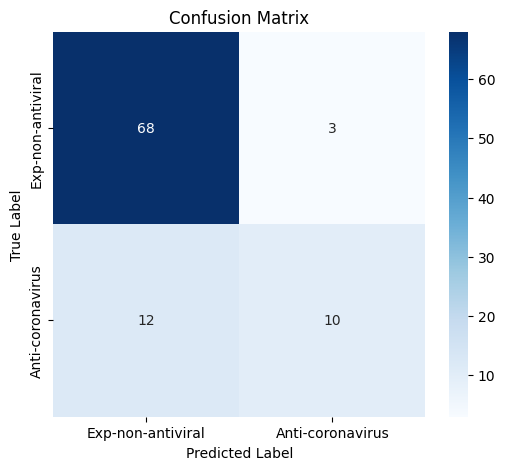


🔹 Classification Report:

                   precision    recall  f1-score   support

Exp-non-antiviral       0.85      0.96      0.90        71
 Anti-coronavirus       0.77      0.45      0.57        22

         accuracy                           0.84        93
        macro avg       0.81      0.71      0.74        93
     weighted avg       0.83      0.84      0.82        93



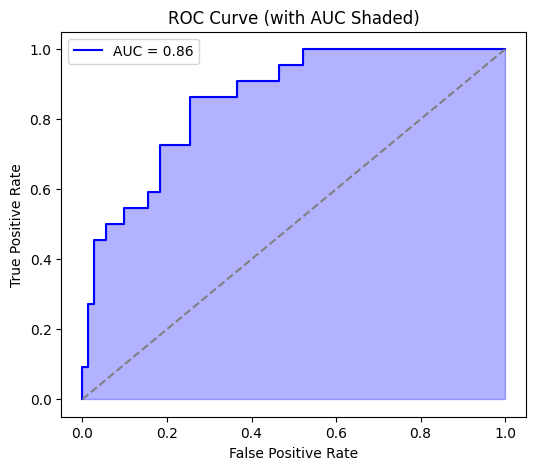

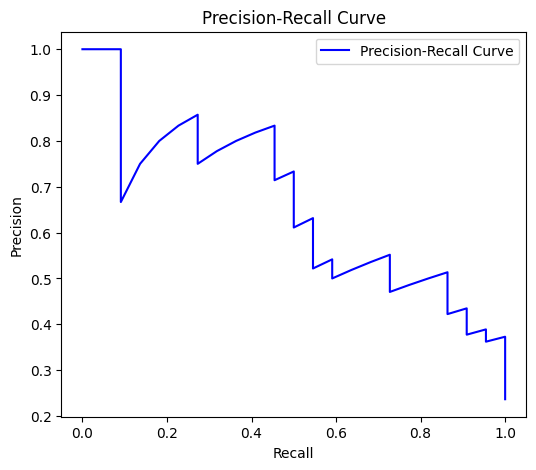

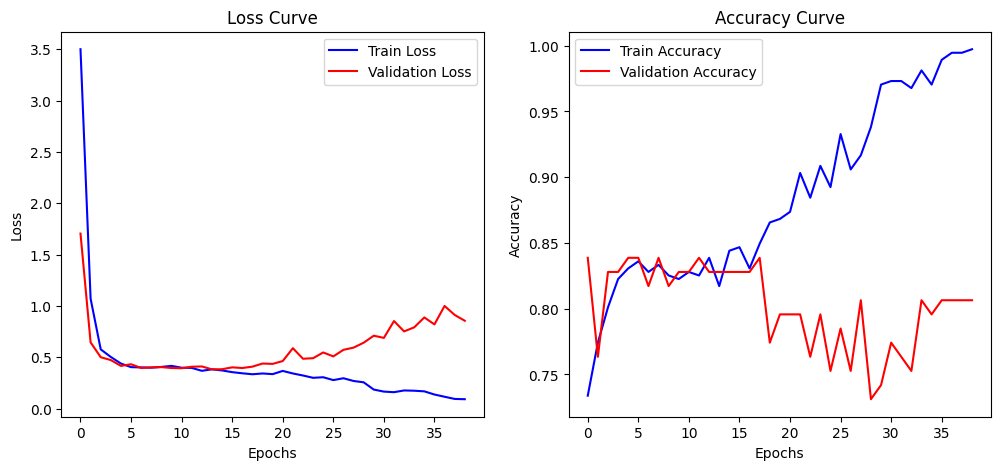

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
3/3 ━━━━━━━━

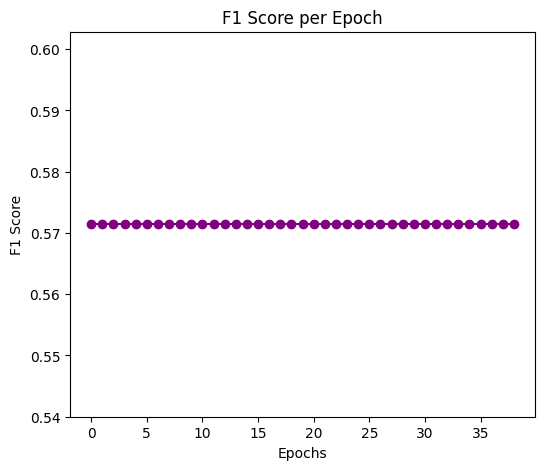

Cohen’s Kappa Score: 0.48
Matthews Correlation Coefficient (MCC): 0.51


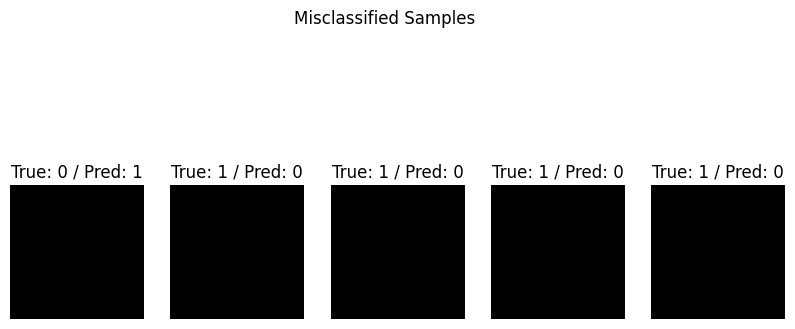


🔟 Performance Metrics Summary Table (For Research Paper)

   Metric  Score
 Accuracy 0.8387
Precision 0.7692
   Recall 0.4545
 F1-score 0.5714
      AUC 0.8572
      MCC 0.5053
   G-mean 0.6598


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_curve, auc, 
    precision_recall_curve, f1_score, cohen_kappa_score, matthews_corrcoef,
    accuracy_score, precision_score, recall_score
)
import pandas as pd
import random

# 🔹 Get model predictions
y_pred_probs = model.predict(X_test)  # Probabilities
y_pred = (y_pred_probs > 0.5).astype(int)  # Binary labels

# 🔹 1️⃣ Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=["Exp-non-antiviral", "Anti-coronavirus"], 
            yticklabels=["Exp-non-antiviral", "Anti-coronavirus"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

# 🔹 2️⃣ Classification Report
print("\n🔹 Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=["Exp-non-antiviral", "Anti-coronavirus"]))

# 🔹 3️⃣ ROC Curve & AUC Score with shaded area
fpr, tpr, _ = roc_curve(y_test, y_pred_probs)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='blue', label=f'AUC = {roc_auc:.2f}')
plt.fill_between(fpr, tpr, alpha=0.3, color='blue')  # shaded area
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (with AUC Shaded)')
plt.legend()
plt.show()

# 🔹 4️⃣ Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_pred_probs)
plt.figure(figsize=(6,5))
plt.plot(recall, precision, color='blue', label='Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

# 🔹 5️⃣ Training Loss & Accuracy Curves
plt.figure(figsize=(12,5))

# Loss Plot
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='red')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.legend()

# Accuracy Plot
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy Curve')
plt.legend()

plt.show()

# 🔹 6️⃣ F1 Score per Epoch (static due to using test set repeatedly)
f1_scores = [f1_score(y_test, (model.predict(X_test) > 0.5).astype(int)) for _ in range(len(history.history['loss']))]
plt.figure(figsize=(6,5))
plt.plot(f1_scores, color='purple', marker='o')
plt.xlabel('Epochs')
plt.ylabel('F1 Score')
plt.title('F1 Score per Epoch')
plt.show()

# 🔹 7️⃣ Cohen’s Kappa Score
kappa_score = cohen_kappa_score(y_test, y_pred)
print(f"Cohen’s Kappa Score: {kappa_score:.2f}")

# 🔹 8️⃣ Matthews Correlation Coefficient (MCC)
mcc = matthews_corrcoef(y_test, y_pred)
print(f"Matthews Correlation Coefficient (MCC): {mcc:.2f}")

# 🔹 9️⃣ Error Analysis (Misclassified Samples)
misclassified_idx = np.where(y_pred.flatten() != y_test.flatten())[0]
if len(misclassified_idx) > 5:  
    misclassified_idx = random.sample(list(misclassified_idx), 5)

plt.figure(figsize=(10,5))
for i, idx in enumerate(misclassified_idx):
    plt.subplot(1, 5, i + 1)
    plt.imshow(X_test[idx].astype("uint8"))
    plt.title(f"True: {y_test[idx]} / Pred: {y_pred[idx][0]}")
    plt.axis("off")
plt.suptitle("Misclassified Samples")
plt.show()

# 🔟 Performance Metrics Summary Table
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

accuracy = accuracy_score(y_test, y_pred)
precision_val = precision_score(y_test, y_pred)
recall_val = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
sensitivity = recall_val
specificity = tn / (tn + fp)
gmean = np.sqrt(sensitivity * specificity)

performance_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "AUC", "MCC", "G-mean"],
    "Score": [accuracy, precision_val, recall_val, f1, roc_auc, mcc, gmean]
})

print("\n🔟 Performance Metrics Summary Table (For Research Paper)\n")
print(performance_df.round(4).to_string(index=False))


**cnn+SE**

In [3]:
import os
import numpy as np
from glob import glob
import cv2
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, regularizers

# Image dimensions
IMG_HEIGHT, IMG_WIDTH = 128, 128  

# Paths to Ennavia C dataset directories
data_dir_anti_coronavirus = "/kaggle/input/spectrogram-imgs-ennavia-c-mol-mass/spectrogram images/anti-coronavirus images"
data_dir_exp_non_antiviral = "/kaggle/input/spectrogram-imgs-ennavia-c-mol-mass/spectrogram images/exp-non-antiviral images"

# Function to load and preprocess images
def load_images_from_directory(directory, label):
    images, labels = [], []
    files = glob(os.path.join(directory, "*.png"))  # PNG images
    for file in files:
        img = cv2.imread(file)
        if img is None:
            continue
        img = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT))
        img = img / 255.0  # Normalize
        images.append(img)
        labels.append(label)
    return np.array(images), np.array(labels)

# Load both classes
X_anticorona, y_anticorona = load_images_from_directory(data_dir_anti_coronavirus, label=1)
X_nonantiviral, y_nonantiviral = load_images_from_directory(data_dir_exp_non_antiviral, label=0)

# Combine data
X = np.concatenate((X_anticorona, X_nonantiviral), axis=0)
y = np.concatenate((y_anticorona, y_nonantiviral), axis=0)

# Split into train and test (80-20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Shuffle training data
train_indices = np.arange(X_train.shape[0])
np.random.shuffle(train_indices)
X_train, y_train = X_train[train_indices], y_train[train_indices]

# Shuffle test data
test_indices = np.arange(X_test.shape[0])
np.random.shuffle(test_indices)
X_test, y_test = X_test[test_indices], y_test[test_indices]

# Squeeze and Excitation Block
def squeeze_excite_block(input_tensor, ratio=16):
    filters = input_tensor.shape[-1]
    se = layers.GlobalAveragePooling2D()(input_tensor)
    se = layers.Dense(filters // ratio, activation="relu")(se)
    se = layers.Dense(filters, activation="sigmoid")(se)
    se = layers.Reshape((1, 1, filters))(se)
    return layers.multiply([input_tensor, se])

# Define CNN Model with SE Attention
def build_se_cnn(input_shape):
    inputs = layers.Input(shape=input_shape)

    # Block 1
    x = layers.Conv2D(32, (5, 5), activation='relu', padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = squeeze_excite_block(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # Block 2
    x = layers.Conv2D(64, (5, 5), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = squeeze_excite_block(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # Block 3 with Residual Connection and SE
    res = layers.Conv2D(128, (3, 3), padding='same')(x)
    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = squeeze_excite_block(x)
    x = layers.Add()([x, res])
    x = layers.MaxPooling2D((2, 2))(x)

    # Block 4
    x = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = squeeze_excite_block(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # Global Pooling and Dense Layers
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.01))(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = models.Model(inputs, outputs)

    # Optimizer with LR scheduler
    lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
        initial_learning_rate=0.001, decay_steps=5000, decay_rate=0.9, staircase=True
    )
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)

    model.compile(optimizer=optimizer,
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

# Build model
model = build_se_cnn((IMG_HEIGHT, IMG_WIDTH, 3))

# Callbacks
early_stopping = callbacks.EarlyStopping(monitor='val_loss', patience=25, restore_best_weights=True)
model_checkpoint = callbacks.ModelCheckpoint("best_se_cnn.keras", monitor='val_accuracy', save_best_only=True)

# Train model
history = model.fit(
    X_train, y_train, batch_size=32, epochs=200,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping, model_checkpoint],
    verbose=1
)

# Load best model and evaluate
model.load_weights("best_se_cnn.keras")
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy: {test_accuracy * 100:.2f}%")

# Save model in Kaggle
tf.keras.models.save_model(model, "/kaggle/working/final_cnn+SE_model.keras")
print("Model saved successfully in /kaggle/working/")


Epoch 1/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 27s 1000ms/step - accuracy: 0.7401 - loss: 3.7812 - val_accuracy: 0.2366 - val_loss: 3.3739
Epoch 2/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.8419 - loss: 2.8918 - val_accuracy: 0.2366 - val_loss: 2.7624
Epoch 3/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.8462 - loss: 2.2172 - val_accuracy: 0.2366 - val_loss: 2.2261
Epoch 4/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.8225 - loss: 1.7270 - val_accuracy: 0.2366 - val_loss: 1.8616
Epoch 5/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.8446 - loss: 1.3286 - val_accuracy: 0.2366 - val_loss: 1.6097
Epoch 6/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.8401 - loss: 1.0579 - val_accuracy: 0.2366 - val_loss: 1.3737
Epoch 7/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.8213 - loss: 0.9280 - val_accuracy: 0.2366 - val_loss: 1.3860
Epoch 8/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.8543 - loss: 0.7094 - val_accuracy:

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 506ms/step


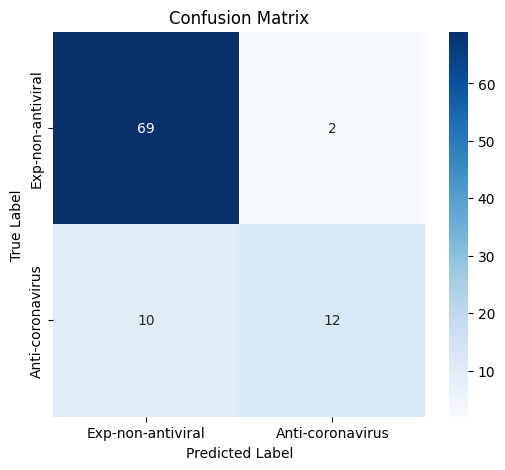


🔹 Classification Report:

                   precision    recall  f1-score   support

Exp-non-antiviral       0.87      0.97      0.92        71
 Anti-coronavirus       0.86      0.55      0.67        22

         accuracy                           0.87        93
        macro avg       0.87      0.76      0.79        93
     weighted avg       0.87      0.87      0.86        93



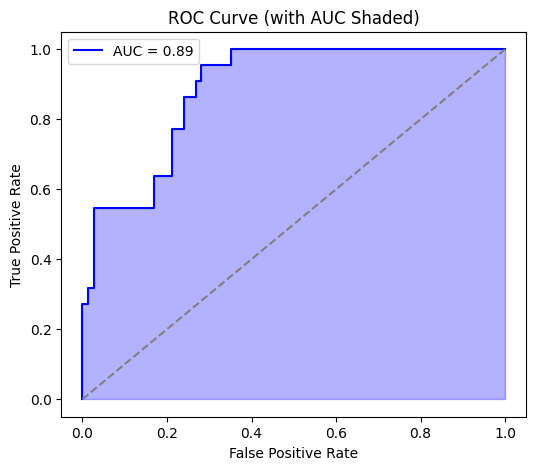

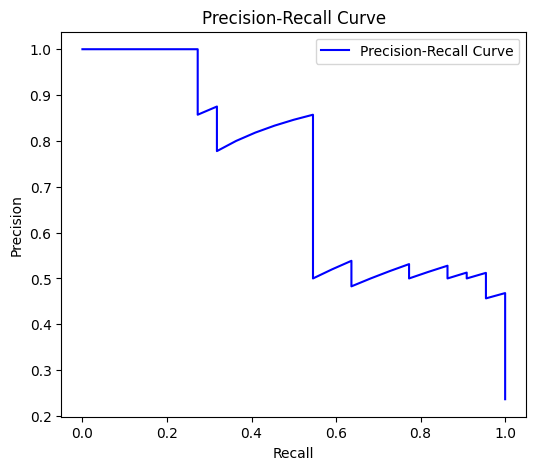

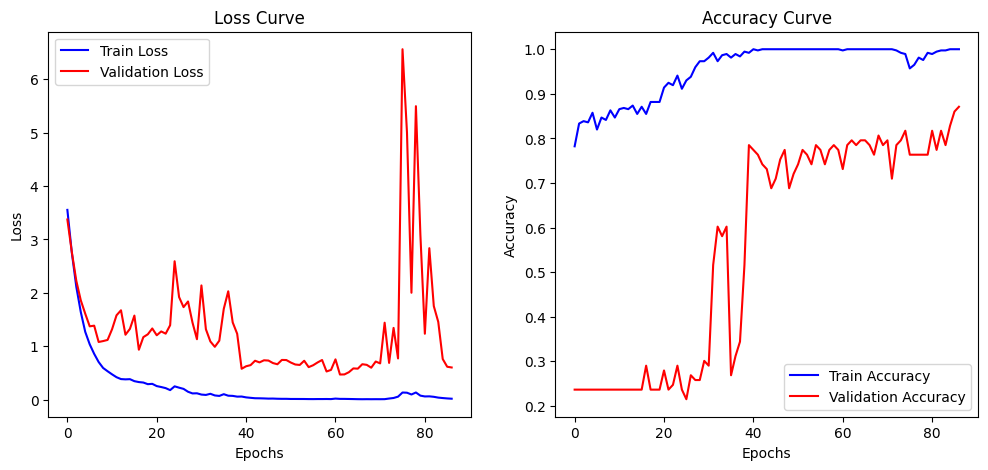

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
3/3 ━━━━━━━━

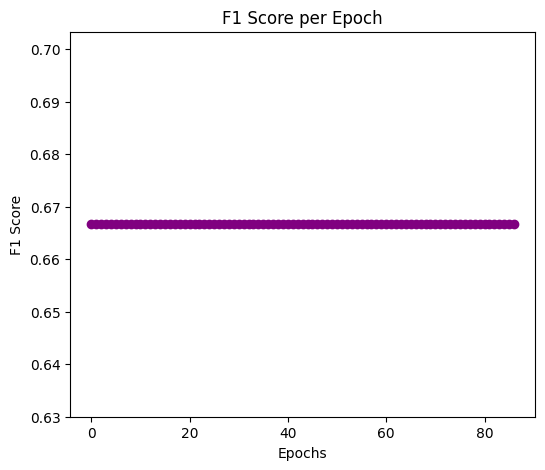

Cohen’s Kappa Score: 0.59
Matthews Correlation Coefficient (MCC): 0.61


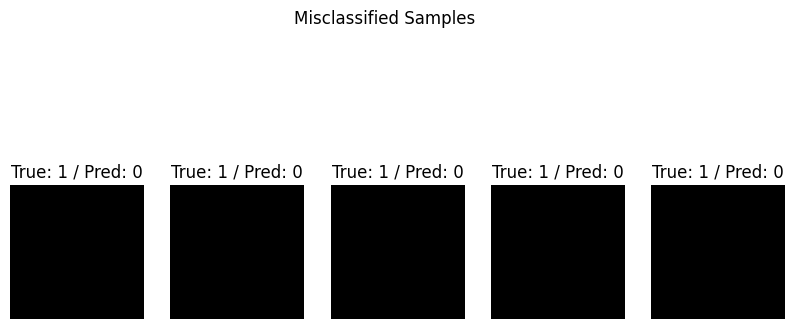


🔟 Performance Metrics Summary Table (For Research Paper)

   Metric  Score
 Accuracy 0.8710
Precision 0.8571
   Recall 0.5455
 F1-score 0.6667
      AUC 0.8860
      MCC 0.6147
   G-mean 0.7281


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_curve, auc, 
    precision_recall_curve, f1_score, cohen_kappa_score, matthews_corrcoef,
    accuracy_score, precision_score, recall_score
)
import pandas as pd
import random

# 🔹 Get model predictions
y_pred_probs = model.predict(X_test)  # Probabilities
y_pred = (y_pred_probs > 0.5).astype(int)  # Binary labels

# 🔹 1️⃣ Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=["Exp-non-antiviral", "Anti-coronavirus"], 
            yticklabels=["Exp-non-antiviral", "Anti-coronavirus"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

# 🔹 2️⃣ Classification Report
print("\n🔹 Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=["Exp-non-antiviral", "Anti-coronavirus"]))

# 🔹 3️⃣ ROC Curve & AUC Score with shaded area
fpr, tpr, _ = roc_curve(y_test, y_pred_probs)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='blue', label=f'AUC = {roc_auc:.2f}')
plt.fill_between(fpr, tpr, alpha=0.3, color='blue')  # shaded area
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (with AUC Shaded)')
plt.legend()
plt.show()

# 🔹 4️⃣ Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_pred_probs)
plt.figure(figsize=(6,5))
plt.plot(recall, precision, color='blue', label='Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

# 🔹 5️⃣ Training Loss & Accuracy Curves
plt.figure(figsize=(12,5))

# Loss Plot
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='red')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.legend()

# Accuracy Plot
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy Curve')
plt.legend()

plt.show()

# 🔹 6️⃣ F1 Score per Epoch (static due to using test set repeatedly)
f1_scores = [f1_score(y_test, (model.predict(X_test) > 0.5).astype(int)) for _ in range(len(history.history['loss']))]
plt.figure(figsize=(6,5))
plt.plot(f1_scores, color='purple', marker='o')
plt.xlabel('Epochs')
plt.ylabel('F1 Score')
plt.title('F1 Score per Epoch')
plt.show()

# 🔹 7️⃣ Cohen’s Kappa Score
kappa_score = cohen_kappa_score(y_test, y_pred)
print(f"Cohen’s Kappa Score: {kappa_score:.2f}")

# 🔹 8️⃣ Matthews Correlation Coefficient (MCC)
mcc = matthews_corrcoef(y_test, y_pred)
print(f"Matthews Correlation Coefficient (MCC): {mcc:.2f}")

# 🔹 9️⃣ Error Analysis (Misclassified Samples)
misclassified_idx = np.where(y_pred.flatten() != y_test.flatten())[0]
if len(misclassified_idx) > 5:  
    misclassified_idx = random.sample(list(misclassified_idx), 5)

plt.figure(figsize=(10,5))
for i, idx in enumerate(misclassified_idx):
    plt.subplot(1, 5, i + 1)
    plt.imshow(X_test[idx].astype("uint8"))
    plt.title(f"True: {y_test[idx]} / Pred: {y_pred[idx][0]}")
    plt.axis("off")
plt.suptitle("Misclassified Samples")
plt.show()

# 🔟 Performance Metrics Summary Table
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

accuracy = accuracy_score(y_test, y_pred)
precision_val = precision_score(y_test, y_pred)
recall_val = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
sensitivity = recall_val
specificity = tn / (tn + fp)
gmean = np.sqrt(sensitivity * specificity)

performance_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "AUC", "MCC", "G-mean"],
    "Score": [accuracy, precision_val, recall_val, f1, roc_auc, mcc, gmean]
})

print("\n🔟 Performance Metrics Summary Table (For Research Paper)\n")
print(performance_df.round(4).to_string(index=False))


**cnn+cbam**

In [5]:
import os
import numpy as np
from glob import glob
import cv2
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, models, callbacks, regularizers

# Paths to directories (Ennavia C dataset)
data_dir_anti_coronavirus = "/kaggle/input/spectrogram-imgs-ennavia-c-mol-mass/spectrogram images/anti-coronavirus images"
data_dir_exp_non_antiviral = "/kaggle/input/spectrogram-imgs-ennavia-c-mol-mass/spectrogram images/exp-non-antiviral images"

# Image dimensions
IMG_HEIGHT, IMG_WIDTH = 128, 128

# Load and preprocess images
def load_images_from_directory(directory, label):
    images, labels = [], []
    files = glob(os.path.join(directory, "*.png"))
    for file in files:
        img = cv2.imread(file)
        if img is None:
            continue
        img = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT))
        img = img / 255.0  # Normalize
        images.append(img)
        labels.append(label)
    return np.array(images), np.array(labels)

# Load images from both classes
X_anticorona, y_anticorona = load_images_from_directory(data_dir_anti_coronavirus, label=1)
X_nonantiviral, y_nonantiviral = load_images_from_directory(data_dir_exp_non_antiviral, label=0)

# Combine data
X = np.concatenate((X_anticorona, X_nonantiviral), axis=0)
y = np.concatenate((y_anticorona, y_nonantiviral), axis=0)

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Shuffle train
indices_train = np.arange(X_train.shape[0])
np.random.shuffle(indices_train)
X_train, y_train = X_train[indices_train], y_train[indices_train]

# Shuffle test
indices_test = np.arange(X_test.shape[0])
np.random.shuffle(indices_test)
X_test, y_test = X_test[indices_test], y_test[indices_test]

# CBAM Attention Module
def cbam_block(input_tensor, reduction_ratio=16):
    filters = input_tensor.shape[-1]

    # Channel attention
    avg_pool = layers.GlobalAveragePooling2D()(input_tensor)
    max_pool = layers.GlobalMaxPooling2D()(input_tensor)

    shared_dense = layers.Dense(filters // reduction_ratio, activation="relu")
    avg_out = shared_dense(avg_pool)
    max_out = shared_dense(max_pool)

    shared_dense_2 = layers.Dense(filters, activation="sigmoid")
    avg_out = shared_dense_2(avg_out)
    max_out = shared_dense_2(max_out)

    avg_out = layers.Reshape((1, 1, filters))(avg_out)
    max_out = layers.Reshape((1, 1, filters))(max_out)

    channel_attention = layers.Add()([avg_out, max_out])
    channel_attention = layers.Activation('sigmoid')(channel_attention)

    x = layers.Multiply()([input_tensor, channel_attention])

    # Spatial attention
    avg_pool = layers.Lambda(lambda x: tf.reduce_mean(x, axis=-1, keepdims=True))(x)
    max_pool = layers.Lambda(lambda x: tf.reduce_max(x, axis=-1, keepdims=True))(x)
    spatial_attention = layers.Concatenate(axis=-1)([avg_pool, max_pool])
    spatial_attention = layers.Conv2D(1, kernel_size=7, padding="same", activation="sigmoid")(spatial_attention)

    output_tensor = layers.Multiply()([x, spatial_attention])
    return output_tensor

# Define CNN + CBAM model
def build_cbam_cnn(input_shape):
    inputs = layers.Input(shape=input_shape)

    # Block 1
    x = layers.Conv2D(32, (5, 5), activation='relu', padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = cbam_block(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # Block 2
    x = layers.Conv2D(64, (5, 5), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = cbam_block(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # Block 3 with residual connection
    res = layers.Conv2D(128, (3, 3), padding='same')(x)
    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = cbam_block(x)
    x = layers.Add()([x, res])
    x = layers.MaxPooling2D((2, 2))(x)

    # Block 4
    x = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = cbam_block(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # Global average pooling and dense layers
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.01))(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = models.Model(inputs, outputs)

    # Learning rate schedule
    lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
        initial_learning_rate=0.001, decay_steps=5000, decay_rate=0.9, staircase=True
    )
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)

    model.compile(optimizer=optimizer,
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

# Instantiate model
model = build_cbam_cnn((IMG_HEIGHT, IMG_WIDTH, 3))

# Callbacks
early_stopping = callbacks.EarlyStopping(monitor='val_loss', patience=25, restore_best_weights=True)
model_checkpoint = callbacks.ModelCheckpoint("best_cbam_cnn.keras", monitor='val_accuracy', save_best_only=True)

# Train model
history = model.fit(
    X_train, y_train, batch_size=32, epochs=200,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping, model_checkpoint],
    verbose=1
)

# Load best weights and evaluate
model.load_weights("best_cbam_cnn.keras")
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy: {test_accuracy * 100:.2f}%")

# Save final model
tf.keras.models.save_model(model, "/kaggle/working/final_cbam_cnn_model.keras")
print("Model saved to /kaggle/working/")


Epoch 1/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 32s 1s/step - accuracy: 0.7392 - loss: 3.7411 - val_accuracy: 0.2366 - val_loss: 3.3844
Epoch 2/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.8595 - loss: 2.8506 - val_accuracy: 0.2366 - val_loss: 2.7689
Epoch 3/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.8729 - loss: 2.2040 - val_accuracy: 0.2366 - val_loss: 2.2871
Epoch 4/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.8313 - loss: 1.7796 - val_accuracy: 0.2366 - val_loss: 1.9157
Epoch 5/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.8116 - loss: 1.4189 - val_accuracy: 0.2366 - val_loss: 1.6544
Epoch 6/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.8432 - loss: 1.0998 - val_accuracy: 0.2366 - val_loss: 1.5434
Epoch 7/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.8821 - loss: 0.8757 - val_accuracy: 0.2366 - val_loss: 1.4272
Epoch 8/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.8805 - loss: 0.7049 - val_accuracy: 0.2

3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 956ms/step


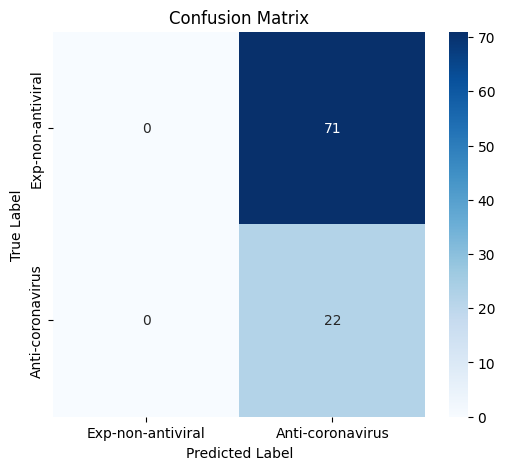


🔹 Classification Report:

                   precision    recall  f1-score   support

Exp-non-antiviral       0.00      0.00      0.00        71
 Anti-coronavirus       0.24      1.00      0.38        22

         accuracy                           0.24        93
        macro avg       0.12      0.50      0.19        93
     weighted avg       0.06      0.24      0.09        93



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


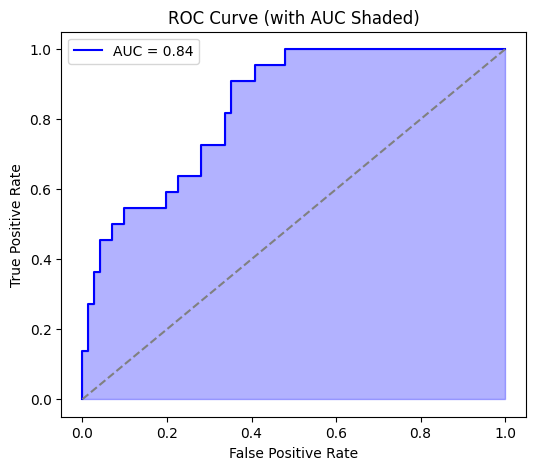

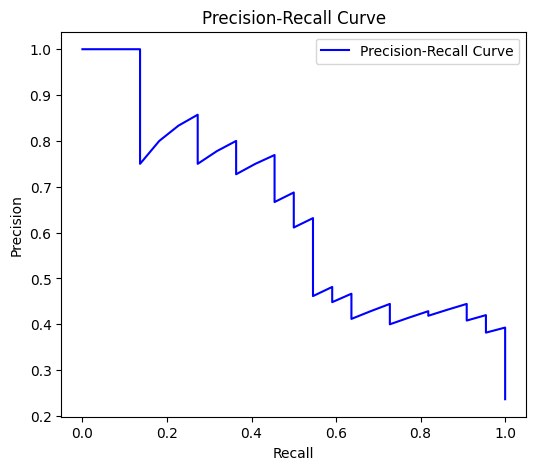

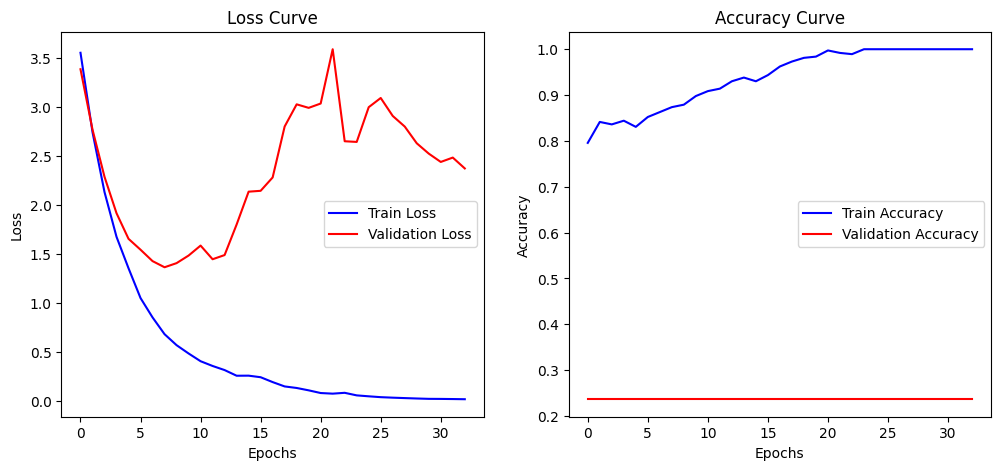

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
3/3 ━━━━━━━━

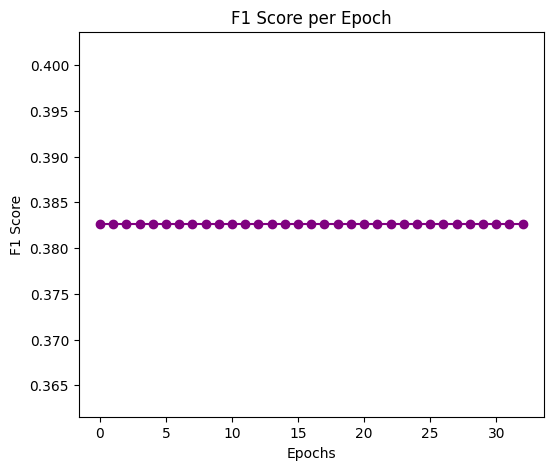

Cohen’s Kappa Score: 0.00
Matthews Correlation Coefficient (MCC): 0.00


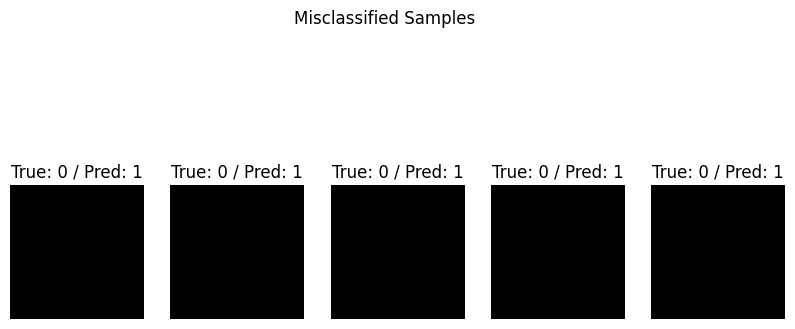


🔟 Performance Metrics Summary Table (For Research Paper)

   Metric  Score
 Accuracy 0.2366
Precision 0.2366
   Recall 1.0000
 F1-score 0.3826
      AUC 0.8361
      MCC 0.0000
   G-mean 0.0000


In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_curve, auc, 
    precision_recall_curve, f1_score, cohen_kappa_score, matthews_corrcoef,
    accuracy_score, precision_score, recall_score
)
import pandas as pd
import random

# 🔹 Get model predictions
y_pred_probs = model.predict(X_test)  # Probabilities
y_pred = (y_pred_probs > 0.5).astype(int)  # Binary labels

# 🔹 1️⃣ Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=["Exp-non-antiviral", "Anti-coronavirus"], 
            yticklabels=["Exp-non-antiviral", "Anti-coronavirus"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

# 🔹 2️⃣ Classification Report
print("\n🔹 Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=["Exp-non-antiviral", "Anti-coronavirus"]))

# 🔹 3️⃣ ROC Curve & AUC Score with shaded area
fpr, tpr, _ = roc_curve(y_test, y_pred_probs)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='blue', label=f'AUC = {roc_auc:.2f}')
plt.fill_between(fpr, tpr, alpha=0.3, color='blue')  # shaded area
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (with AUC Shaded)')
plt.legend()
plt.show()

# 🔹 4️⃣ Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_pred_probs)
plt.figure(figsize=(6,5))
plt.plot(recall, precision, color='blue', label='Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

# 🔹 5️⃣ Training Loss & Accuracy Curves
plt.figure(figsize=(12,5))

# Loss Plot
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='red')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.legend()

# Accuracy Plot
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy Curve')
plt.legend()

plt.show()

# 🔹 6️⃣ F1 Score per Epoch (static due to using test set repeatedly)
f1_scores = [f1_score(y_test, (model.predict(X_test) > 0.5).astype(int)) for _ in range(len(history.history['loss']))]
plt.figure(figsize=(6,5))
plt.plot(f1_scores, color='purple', marker='o')
plt.xlabel('Epochs')
plt.ylabel('F1 Score')
plt.title('F1 Score per Epoch')
plt.show()

# 🔹 7️⃣ Cohen’s Kappa Score
kappa_score = cohen_kappa_score(y_test, y_pred)
print(f"Cohen’s Kappa Score: {kappa_score:.2f}")

# 🔹 8️⃣ Matthews Correlation Coefficient (MCC)
mcc = matthews_corrcoef(y_test, y_pred)
print(f"Matthews Correlation Coefficient (MCC): {mcc:.2f}")

# 🔹 9️⃣ Error Analysis (Misclassified Samples)
misclassified_idx = np.where(y_pred.flatten() != y_test.flatten())[0]
if len(misclassified_idx) > 5:  
    misclassified_idx = random.sample(list(misclassified_idx), 5)

plt.figure(figsize=(10,5))
for i, idx in enumerate(misclassified_idx):
    plt.subplot(1, 5, i + 1)
    plt.imshow(X_test[idx].astype("uint8"))
    plt.title(f"True: {y_test[idx]} / Pred: {y_pred[idx][0]}")
    plt.axis("off")
plt.suptitle("Misclassified Samples")
plt.show()

# 🔟 Performance Metrics Summary Table
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

accuracy = accuracy_score(y_test, y_pred)
precision_val = precision_score(y_test, y_pred)
recall_val = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
sensitivity = recall_val
specificity = tn / (tn + fp)
gmean = np.sqrt(sensitivity * specificity)

performance_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "AUC", "MCC", "G-mean"],
    "Score": [accuracy, precision_val, recall_val, f1, roc_auc, mcc, gmean]
})

print("\n🔟 Performance Metrics Summary Table (For Research Paper)\n")
print(performance_df.round(4).to_string(index=False))


**resnet50**

In [7]:
import os
import numpy as np
from glob import glob
import cv2
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, models, callbacks, applications, regularizers

# Set image dimensions
IMG_HEIGHT, IMG_WIDTH = 224, 224

# Dataset directories
data_dir_anti_coronavirus = "/kaggle/input/spectrogram-imgs-ennavia-c-mol-mass/spectrogram images/anti-coronavirus images"
data_dir_exp_non_antiviral = "/kaggle/input/spectrogram-imgs-ennavia-c-mol-mass/spectrogram images/exp-non-antiviral images"

# Function to load and preprocess images
def load_images_from_directory(directory, label):
    images, labels = [], []
    files = glob(os.path.join(directory, "*.png"))
    for file in files:
        img = cv2.imread(file)
        if img is None:
            continue
        img = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT))
        img = img / 255.0  # Normalize to [0,1]
        images.append(img)
        labels.append(label)
    return np.array(images), np.array(labels)

# Load both classes (corrected variable name)
X_antiviral, y_antiviral = load_images_from_directory(data_dir_anti_coronavirus, label=1)
X_non_antiviral, y_non_antiviral = load_images_from_directory(data_dir_exp_non_antiviral, label=0)

# Combine data
X = np.concatenate((X_antiviral, X_non_antiviral), axis=0)
y = np.concatenate((y_antiviral, y_non_antiviral), axis=0)

# Shuffle and split into train and test (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Build ResNet50-based model
def build_resnet_model(input_shape):
    base_model = applications.ResNet50(
        weights='imagenet',
        include_top=False,
        input_shape=input_shape
    )
    for layer in base_model.layers[:140]:
        layer.trainable = False

    inputs = layers.Input(shape=input_shape)
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.01))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = models.Model(inputs, outputs)

    lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
        initial_learning_rate=0.0001,
        decay_steps=5000,
        decay_rate=0.9,
        staircase=True
    )
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)

    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

# Instantiate model
model = build_resnet_model((IMG_HEIGHT, IMG_WIDTH, 3))

# Callbacks
early_stopping = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=25,
    restore_best_weights=True
)
model_checkpoint = callbacks.ModelCheckpoint(
    "best_resnet_model.keras",
    monitor='val_accuracy',
    save_best_only=True
)

# Train model
history = model.fit(
    X_train, y_train,
    batch_size=32,
    epochs=200,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping, model_checkpoint],
    verbose=1
)

# Load best weights and evaluate
model.load_weights("best_resnet_model.keras")
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy: {test_accuracy * 100:.2f}%")

# Save final model
tf.keras.models.save_model(model, "/kaggle/working/final_resnet50_model.keras")
print("Model saved successfully in /kaggle/working/")


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Epoch 1/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 52s 2s/step - accuracy: 0.6577 - loss: 5.3143 - val_accuracy: 0.7634 - val_loss: 5.0706
Epoch 2/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 196ms/step - accuracy: 0.8053 - loss: 4.9595 - val_accuracy: 0.7634 - val_loss: 4.9740
Epoch 3/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 197ms/step - accuracy: 0.7911 - loss: 4.8789 - val_accuracy: 0.7634 - val_loss: 4.8764
Epoch 4/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 198ms/step - accuracy: 0.8516 - loss: 4.7555 - val_accuracy: 0.7634 - val_loss: 4.7778
Epoch 5/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 196ms/step - accuracy: 0.8434 - loss: 4.5540 - val_accuracy: 0.7634 - val_loss: 4.6833
Epoch 6/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 194ms/step - accuracy: 0.9318 - loss: 4.3118 - val_accuracy: 0.7634 - val_loss: 4.5905
Epoch 7/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 194ms/step - accuracy: 0.9040 - loss: 4.2258 - val_accuracy: 0.7634 - val_loss: 4.5019
Epoch 8/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 195ms/

3/3 ━━━━━━━━━━━━━━━━━━━━ 10s 3s/step 


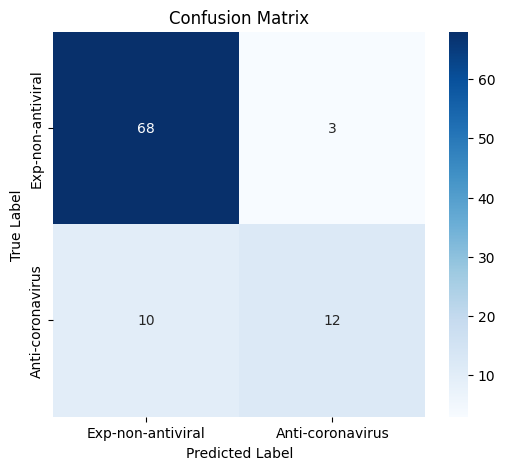


🔹 Classification Report:

                   precision    recall  f1-score   support

Exp-non-antiviral       0.87      0.96      0.91        71
 Anti-coronavirus       0.80      0.55      0.65        22

         accuracy                           0.86        93
        macro avg       0.84      0.75      0.78        93
     weighted avg       0.85      0.86      0.85        93



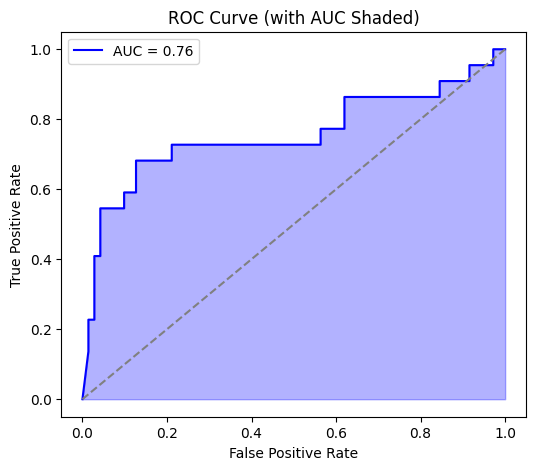

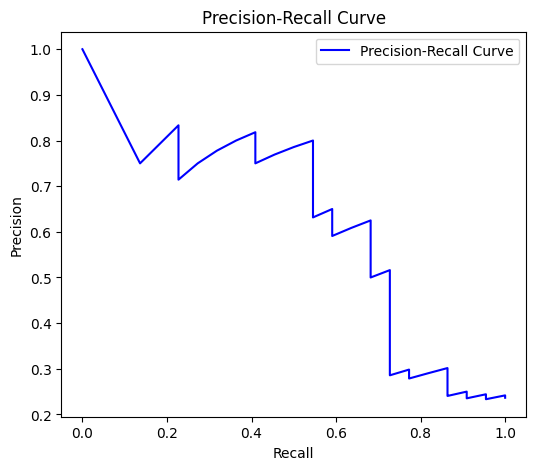

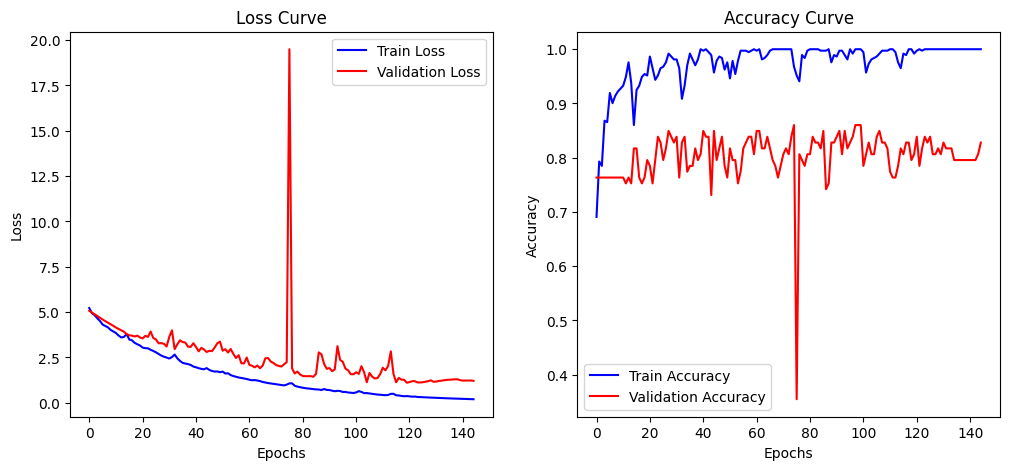

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
3/3 ━━

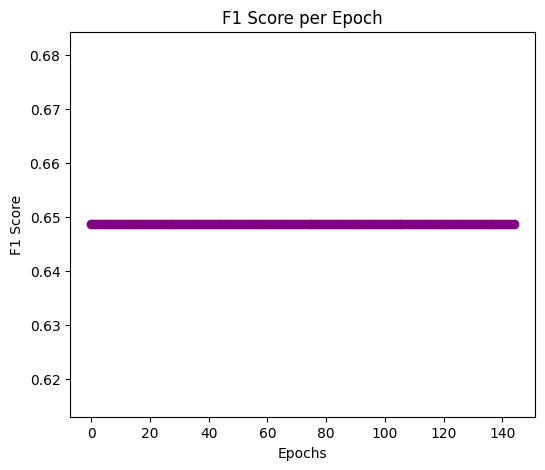

Cohen’s Kappa Score: 0.57
Matthews Correlation Coefficient (MCC): 0.58


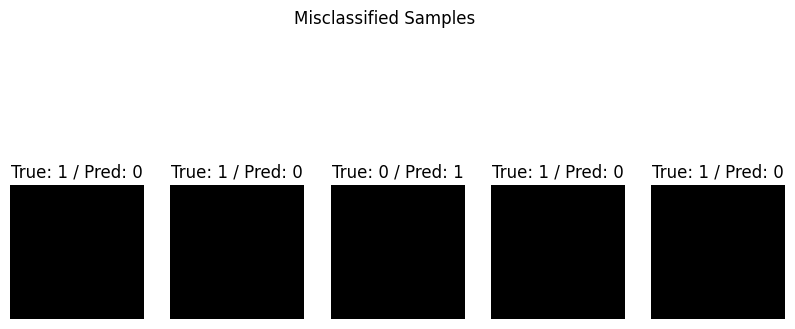


🔟 Performance Metrics Summary Table (For Research Paper)

   Metric  Score
 Accuracy 0.8602
Precision 0.8000
   Recall 0.5455
 F1-score 0.6486
      AUC 0.7551
      MCC 0.5814
   G-mean 0.7228


In [8]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_curve, auc, 
    precision_recall_curve, f1_score, cohen_kappa_score, matthews_corrcoef,
    accuracy_score, precision_score, recall_score
)
import pandas as pd
import random

# 🔹 Get model predictions
y_pred_probs = model.predict(X_test)  # Probabilities
y_pred = (y_pred_probs > 0.5).astype(int)  # Binary labels

# 🔹 1️⃣ Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=["Exp-non-antiviral", "Anti-coronavirus"], 
            yticklabels=["Exp-non-antiviral", "Anti-coronavirus"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

# 🔹 2️⃣ Classification Report
print("\n🔹 Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=["Exp-non-antiviral", "Anti-coronavirus"]))

# 🔹 3️⃣ ROC Curve & AUC Score with shaded area
fpr, tpr, _ = roc_curve(y_test, y_pred_probs)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='blue', label=f'AUC = {roc_auc:.2f}')
plt.fill_between(fpr, tpr, alpha=0.3, color='blue')  # shaded area
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (with AUC Shaded)')
plt.legend()
plt.show()

# 🔹 4️⃣ Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_pred_probs)
plt.figure(figsize=(6,5))
plt.plot(recall, precision, color='blue', label='Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

# 🔹 5️⃣ Training Loss & Accuracy Curves
plt.figure(figsize=(12,5))

# Loss Plot
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='red')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.legend()

# Accuracy Plot
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy Curve')
plt.legend()

plt.show()

# 🔹 6️⃣ F1 Score per Epoch (static due to using test set repeatedly)
f1_scores = [f1_score(y_test, (model.predict(X_test) > 0.5).astype(int)) for _ in range(len(history.history['loss']))]
plt.figure(figsize=(6,5))
plt.plot(f1_scores, color='purple', marker='o')
plt.xlabel('Epochs')
plt.ylabel('F1 Score')
plt.title('F1 Score per Epoch')
plt.show()

# 🔹 7️⃣ Cohen’s Kappa Score
kappa_score = cohen_kappa_score(y_test, y_pred)
print(f"Cohen’s Kappa Score: {kappa_score:.2f}")

# 🔹 8️⃣ Matthews Correlation Coefficient (MCC)
mcc = matthews_corrcoef(y_test, y_pred)
print(f"Matthews Correlation Coefficient (MCC): {mcc:.2f}")

# 🔹 9️⃣ Error Analysis (Misclassified Samples)
misclassified_idx = np.where(y_pred.flatten() != y_test.flatten())[0]
if len(misclassified_idx) > 5:  
    misclassified_idx = random.sample(list(misclassified_idx), 5)

plt.figure(figsize=(10,5))
for i, idx in enumerate(misclassified_idx):
    plt.subplot(1, 5, i + 1)
    plt.imshow(X_test[idx].astype("uint8"))
    plt.title(f"True: {y_test[idx]} / Pred: {y_pred[idx][0]}")
    plt.axis("off")
plt.suptitle("Misclassified Samples")
plt.show()

# 🔟 Performance Metrics Summary Table
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

accuracy = accuracy_score(y_test, y_pred)
precision_val = precision_score(y_test, y_pred)
recall_val = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
sensitivity = recall_val
specificity = tn / (tn + fp)
gmean = np.sqrt(sensitivity * specificity)

performance_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "AUC", "MCC", "G-mean"],
    "Score": [accuracy, precision_val, recall_val, f1, roc_auc, mcc, gmean]
})

print("\n🔟 Performance Metrics Summary Table (For Research Paper)\n")
print(performance_df.round(4).to_string(index=False))


**resnet 50 +SE**

In [9]:
import os
import numpy as np
from glob import glob
import cv2
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, models, callbacks, applications, regularizers

# Image dimensions for ResNet50
IMG_HEIGHT, IMG_WIDTH = 224, 224  

# Paths to the two Ennavia C class directories
data_dir_anti_coronavirus = "/kaggle/input/spectrogram-imgs-ennavia-c-mol-mass/spectrogram images/anti-coronavirus images"
data_dir_exp_non_antiviral = "/kaggle/input/spectrogram-imgs-ennavia-c-mol-mass/spectrogram images/exp-non-antiviral images"


# Function to load & preprocess all images in a directory
def load_images_from_directory(directory, label):
    images, labels = [], []
    for file in glob(os.path.join(directory, "*.png")):
        img = cv2.imread(file)
        if img is None:
            continue
        img = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT))
        img = img.astype("float32") / 255.0
        images.append(img)
        labels.append(label)
    return np.array(images), np.array(labels)

# Load both classes
X_anti, y_anti   = load_images_from_directory(data_dir_anti_coronavirus, label=1)
X_non,  y_non    = load_images_from_directory(data_dir_exp_non_antiviral,   label=0)

# Combine and split (80% train / 20% test)
X = np.concatenate([X_anti, X_non], axis=0)
y = np.concatenate([y_anti, y_non], axis=0)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Squeeze-and-Excitation block
def squeeze_excite_block(input_tensor, ratio=16):
    filters = input_tensor.shape[-1]
    se = layers.GlobalAveragePooling2D()(input_tensor)
    se = layers.Dense(filters // ratio, activation="relu")(se)
    se = layers.Dense(filters, activation="sigmoid")(se)
    se = layers.Reshape((1, 1, filters))(se)
    return layers.Multiply()([input_tensor, se])

# Build ResNet50 + SE model
def build_resnet_se(input_shape):
    base = applications.ResNet50(
        weights="imagenet",
        include_top=False,
        input_shape=input_shape
    )
    # Freeze early layers
    for layer in base.layers[:140]:
        layer.trainable = False

    inputs = layers.Input(shape=input_shape)
    x = base(inputs, training=False)
    x = squeeze_excite_block(x)                     # SE block after backbone
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation="relu",
                    kernel_regularizer=regularizers.l2(0.01))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = models.Model(inputs, outputs)

    lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
        initial_learning_rate=1e-4,
        decay_steps=5000,
        decay_rate=0.9,
        staircase=True
    )
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

# Instantiate and train
model = build_resnet_se((IMG_HEIGHT, IMG_WIDTH, 3))

early_stop = callbacks.EarlyStopping(
    monitor="val_loss", patience=15, restore_best_weights=True
)
checkpoint = callbacks.ModelCheckpoint(
    "best_resnet_se.keras", monitor="val_accuracy", save_best_only=True
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    batch_size=32,
    epochs=200,
    callbacks=[early_stop, checkpoint],
    verbose=1
)

# Evaluate and save
model.load_weights("best_resnet_se.keras")
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy: {acc * 100:.2f}%")

model.save("/kaggle/working/final_resnet50_se_model.keras", include_optimizer=False)
print("Model saved to /kaggle/working/final_resnet50_se_model.keras")


Epoch 1/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 42s 2s/step - accuracy: 0.6933 - loss: 5.2984 - val_accuracy: 0.7634 - val_loss: 5.0895
Epoch 2/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 181ms/step - accuracy: 0.7708 - loss: 4.9542 - val_accuracy: 0.7634 - val_loss: 4.9881
Epoch 3/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 179ms/step - accuracy: 0.8251 - loss: 4.7799 - val_accuracy: 0.7634 - val_loss: 4.8697
Epoch 4/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 181ms/step - accuracy: 0.8659 - loss: 4.6018 - val_accuracy: 0.7634 - val_loss: 4.7639
Epoch 5/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 182ms/step - accuracy: 0.8598 - loss: 4.5405 - val_accuracy: 0.7634 - val_loss: 4.6639
Epoch 6/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 185ms/step - accuracy: 0.8779 - loss: 4.3773 - val_accuracy: 0.7634 - val_loss: 4.5697
Epoch 7/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 186ms/step - accuracy: 0.9201 - loss: 4.1988 - val_accuracy: 0.7634 - val_loss: 4.4731
Epoch 8/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 190ms/step - accuracy: 0.9479 - loss: 4.0445 - val_accura

3/3 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step  


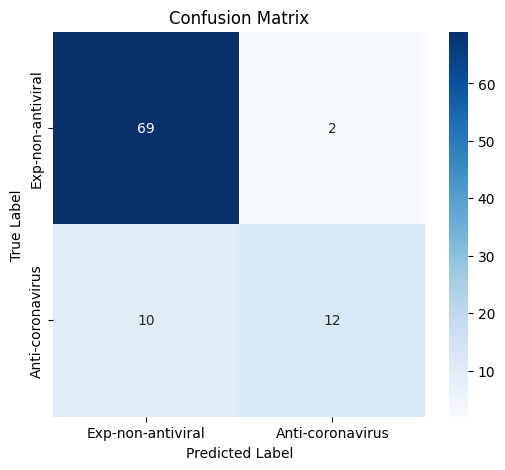


🔹 Classification Report:

                   precision    recall  f1-score   support

Exp-non-antiviral       0.87      0.97      0.92        71
 Anti-coronavirus       0.86      0.55      0.67        22

         accuracy                           0.87        93
        macro avg       0.87      0.76      0.79        93
     weighted avg       0.87      0.87      0.86        93



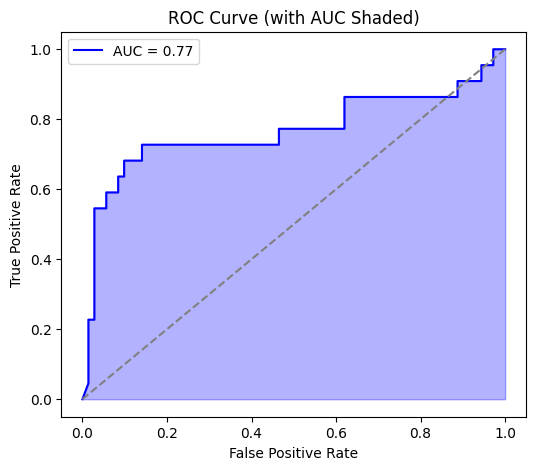

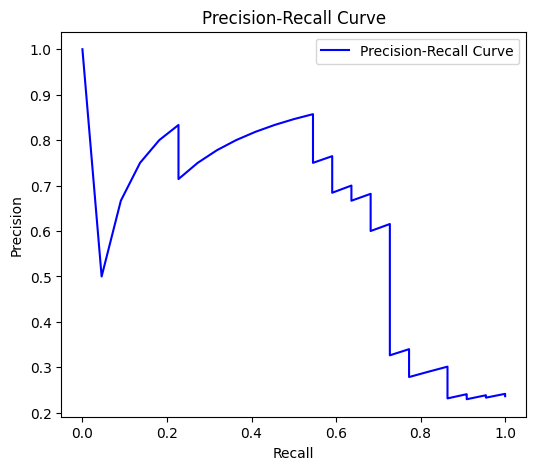

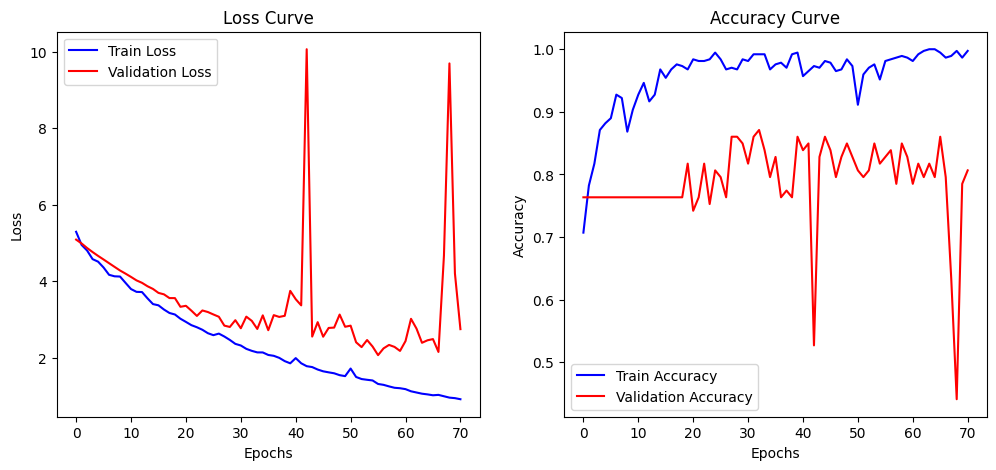

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/ste

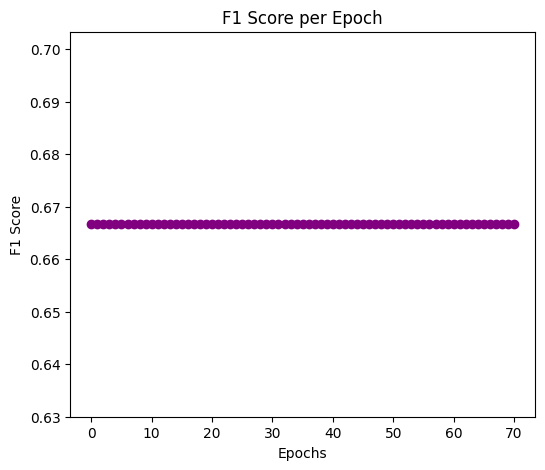

Cohen’s Kappa Score: 0.59
Matthews Correlation Coefficient (MCC): 0.61


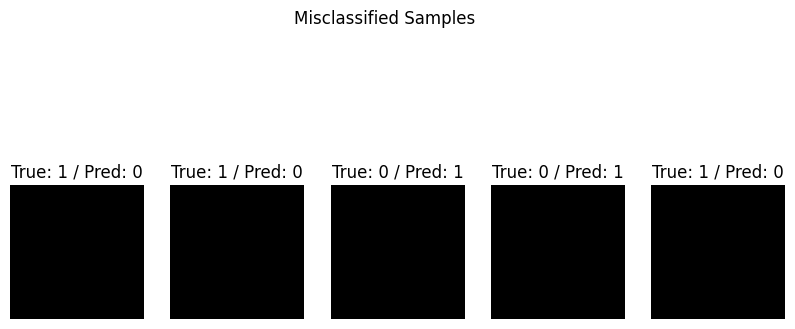


🔟 Performance Metrics Summary Table (For Research Paper)

   Metric  Score
 Accuracy 0.8710
Precision 0.8571
   Recall 0.5455
 F1-score 0.6667
      AUC 0.7660
      MCC 0.6147
   G-mean 0.7281


In [10]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_curve, auc, 
    precision_recall_curve, f1_score, cohen_kappa_score, matthews_corrcoef,
    accuracy_score, precision_score, recall_score
)
import pandas as pd
import random

# 🔹 Get model predictions
y_pred_probs = model.predict(X_test)  # Probabilities
y_pred = (y_pred_probs > 0.5).astype(int)  # Binary labels

# 🔹 1️⃣ Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=["Exp-non-antiviral", "Anti-coronavirus"], 
            yticklabels=["Exp-non-antiviral", "Anti-coronavirus"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

# 🔹 2️⃣ Classification Report
print("\n🔹 Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=["Exp-non-antiviral", "Anti-coronavirus"]))

# 🔹 3️⃣ ROC Curve & AUC Score with shaded area
fpr, tpr, _ = roc_curve(y_test, y_pred_probs)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='blue', label=f'AUC = {roc_auc:.2f}')
plt.fill_between(fpr, tpr, alpha=0.3, color='blue')  # shaded area
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (with AUC Shaded)')
plt.legend()
plt.show()

# 🔹 4️⃣ Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_pred_probs)
plt.figure(figsize=(6,5))
plt.plot(recall, precision, color='blue', label='Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

# 🔹 5️⃣ Training Loss & Accuracy Curves
plt.figure(figsize=(12,5))

# Loss Plot
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='red')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.legend()

# Accuracy Plot
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy Curve')
plt.legend()

plt.show()

# 🔹 6️⃣ F1 Score per Epoch (static due to using test set repeatedly)
f1_scores = [f1_score(y_test, (model.predict(X_test) > 0.5).astype(int)) for _ in range(len(history.history['loss']))]
plt.figure(figsize=(6,5))
plt.plot(f1_scores, color='purple', marker='o')
plt.xlabel('Epochs')
plt.ylabel('F1 Score')
plt.title('F1 Score per Epoch')
plt.show()

# 🔹 7️⃣ Cohen’s Kappa Score
kappa_score = cohen_kappa_score(y_test, y_pred)
print(f"Cohen’s Kappa Score: {kappa_score:.2f}")

# 🔹 8️⃣ Matthews Correlation Coefficient (MCC)
mcc = matthews_corrcoef(y_test, y_pred)
print(f"Matthews Correlation Coefficient (MCC): {mcc:.2f}")

# 🔹 9️⃣ Error Analysis (Misclassified Samples)
misclassified_idx = np.where(y_pred.flatten() != y_test.flatten())[0]
if len(misclassified_idx) > 5:  
    misclassified_idx = random.sample(list(misclassified_idx), 5)

plt.figure(figsize=(10,5))
for i, idx in enumerate(misclassified_idx):
    plt.subplot(1, 5, i + 1)
    plt.imshow(X_test[idx].astype("uint8"))
    plt.title(f"True: {y_test[idx]} / Pred: {y_pred[idx][0]}")
    plt.axis("off")
plt.suptitle("Misclassified Samples")
plt.show()

# 🔟 Performance Metrics Summary Table
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

accuracy = accuracy_score(y_test, y_pred)
precision_val = precision_score(y_test, y_pred)
recall_val = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
sensitivity = recall_val
specificity = tn / (tn + fp)
gmean = np.sqrt(sensitivity * specificity)

performance_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "AUC", "MCC", "G-mean"],
    "Score": [accuracy, precision_val, recall_val, f1, roc_auc, mcc, gmean]
})

print("\n🔟 Performance Metrics Summary Table (For Research Paper)\n")
print(performance_df.round(4).to_string(index=False))


**resnet 50 + CBAM**

In [11]:
import os
import numpy as np
from glob import glob
import cv2
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import layers, models, callbacks, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet import preprocess_input
from tensorflow.keras.layers import (
    GlobalAveragePooling2D, GlobalMaxPooling2D, Dense, Reshape, Multiply,
    Conv2D, Add, Activation, Lambda, Dropout
)
from tensorflow.keras import backend as K
from sklearn.model_selection import train_test_split

# Paths to directories
data_dir_anti_coronavirus = "/kaggle/input/spectrogram-imgs-ennavia-c-mol-mass/spectrogram images/anti-coronavirus images"
data_dir_exp_non_antiviral = "/kaggle/input/spectrogram-imgs-ennavia-c-mol-mass/spectrogram images/exp-non-antiviral images"


# Image dimensions
IMG_HEIGHT, IMG_WIDTH = 224, 224
TEST_SIZE = 0.2
RANDOM_STATE = 42

# Function to load and preprocess images
def load_images_from_directory(directory, label):
    images, labels = [], []
    files = glob(os.path.join(directory, "*.png"))
    for file in files:
        img = cv2.imread(file)
        if img is None:
            continue
        img = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT))
        img = preprocess_input(img)
        images.append(img)
        labels.append(label)
    return np.array(images), np.array(labels)

# Load datasets
X_anti_corona, y_anti_corona = load_images_from_directory(data_dir_anti_coronavirus, label=1)
X_non_antiviral, y_non_antiviral = load_images_from_directory(data_dir_exp_non_antiviral, label=0)

# Combine datasets
X = np.concatenate((X_anti_corona, X_non_antiviral), axis=0)
y = np.concatenate((y_anti_corona, y_non_antiviral), axis=0)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

# Shuffle training data
indices = np.arange(X_train.shape[0])
np.random.shuffle(indices)
X_train, y_train = X_train[indices], y_train[indices]

# Data augmentation
datagen = ImageDataGenerator(
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.8, 1.2],
)

# CBAM block
def cbam_block(input_tensor, ratio=8):
    channel_avg = GlobalAveragePooling2D()(input_tensor)
    channel_max = GlobalMaxPooling2D()(input_tensor)

    channel_avg = Dense(input_tensor.shape[-1] // ratio, activation='relu')(channel_avg)
    channel_avg = Dense(input_tensor.shape[-1])(channel_avg)

    channel_max = Dense(input_tensor.shape[-1] // ratio, activation='relu')(channel_max)
    channel_max = Dense(input_tensor.shape[-1])(channel_max)

    channel_att = Add()([channel_avg, channel_max])
    channel_att = Activation('sigmoid')(channel_att)
    channel_att = Reshape((1, 1, input_tensor.shape[-1]))(channel_att)
    channel_refined = Multiply()([input_tensor, channel_att])

    avg_pool = Lambda(lambda x: tf.reduce_mean(x, axis=-1, keepdims=True))(channel_refined)
    max_pool = Lambda(lambda x: tf.reduce_max(x, axis=-1, keepdims=True))(channel_refined)
    concat = Add()([avg_pool, max_pool])
    spatial_att = Conv2D(1, kernel_size=7, padding='same', activation='sigmoid')(concat)
    spatial_refined = Multiply()([channel_refined, spatial_att])

    return spatial_refined

# Build ResNet50 with CBAM
def build_resnet_cbam_model(input_shape):
    base_model = ResNet50(weights='imagenet', include_top=False, input_shape=input_shape)

    for layer in base_model.layers[:143]:
        layer.trainable = False
    for layer in base_model.layers[143:]:
        layer.trainable = True

    x = cbam_block(base_model.output)
    x = GlobalAveragePooling2D()(x)
    x = Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.01))(x)
    x = Dropout(0.5)(x)
    outputs = Dense(1, activation='sigmoid')(x)

    model = models.Model(inputs=base_model.input, outputs=outputs)

    lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
        initial_learning_rate=0.0001,
        decay_steps=10000,
        decay_rate=0.9,
        staircase=True
    )
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)

    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Build and train the model
model = build_resnet_cbam_model((IMG_HEIGHT, IMG_WIDTH, 3))

early_stopping = callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
model_checkpoint = callbacks.ModelCheckpoint("best_resnet_cbam_model.keras", monitor='val_accuracy', save_best_only=True)

history = model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    epochs=200,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping, model_checkpoint],
    verbose=1
)

# Evaluate and save model
model.load_weights("best_resnet_cbam_model.keras")
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy with CBAM: {test_accuracy * 100:.2f}%")

tf.keras.models.save_model(model, "/kaggle/working/final_resnet50+CBAM_model.keras")
print("Model saved successfully in /kaggle/working/")


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 43s 2s/step - accuracy: 0.6929 - loss: 8.6569 - val_accuracy: 0.7634 - val_loss: 8.2496
Epoch 2/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 179ms/step - accuracy: 0.7700 - loss: 7.9503 - val_accuracy: 0.7634 - val_loss: 7.7126
Epoch 3/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 181ms/step - accuracy: 0.7980 - loss: 7.4006 - val_accuracy: 0.7634 - val_loss: 7.1993
Epoch 4/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 185ms/step - accuracy: 0.8247 - loss: 6.8815 - val_accuracy: 0.7634 - val_loss: 6.7219
Epoch 5/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 320ms/step - accuracy: 0.8188 - loss: 6.4625 - val_accuracy: 0.8065 - val_loss: 6.2635
Epoch 6/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 331ms/step - accuracy: 0.8470 - loss: 6.0040 - val_accuracy: 0.8280 - val_loss: 5.8360
Epoch 7/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 333ms/step - accuracy: 0.8306 - loss: 5.6065 - val_accuracy: 0.8495 - val_loss: 5.4421
Epoch 8/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 197ms/step - accuracy: 0.8442 - loss: 5.2389 - val_accura

3/3 ━━━━━━━━━━━━━━━━━━━━ 10s 3s/step 


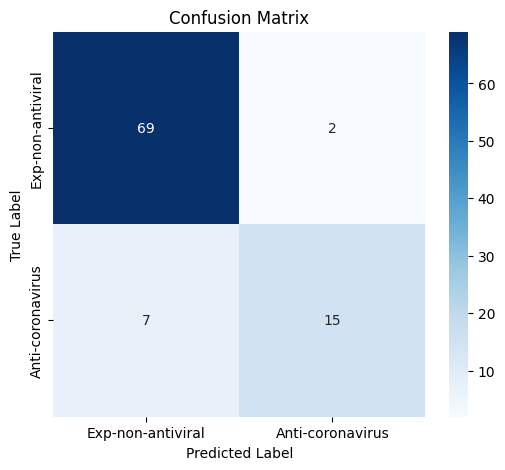


🔹 Classification Report:

                   precision    recall  f1-score   support

Exp-non-antiviral       0.91      0.97      0.94        71
 Anti-coronavirus       0.88      0.68      0.77        22

         accuracy                           0.90        93
        macro avg       0.90      0.83      0.85        93
     weighted avg       0.90      0.90      0.90        93



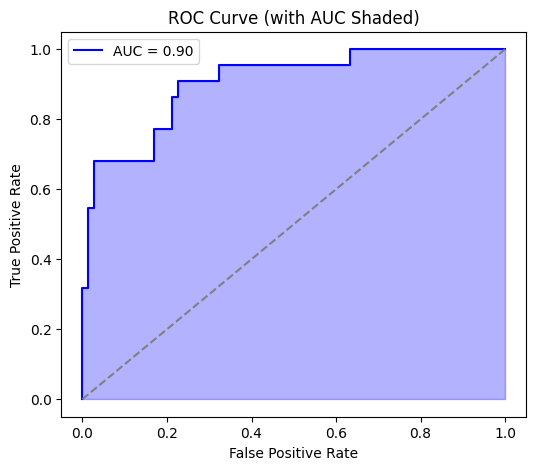

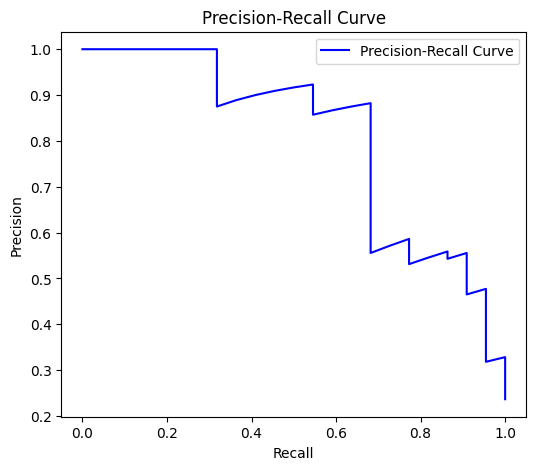

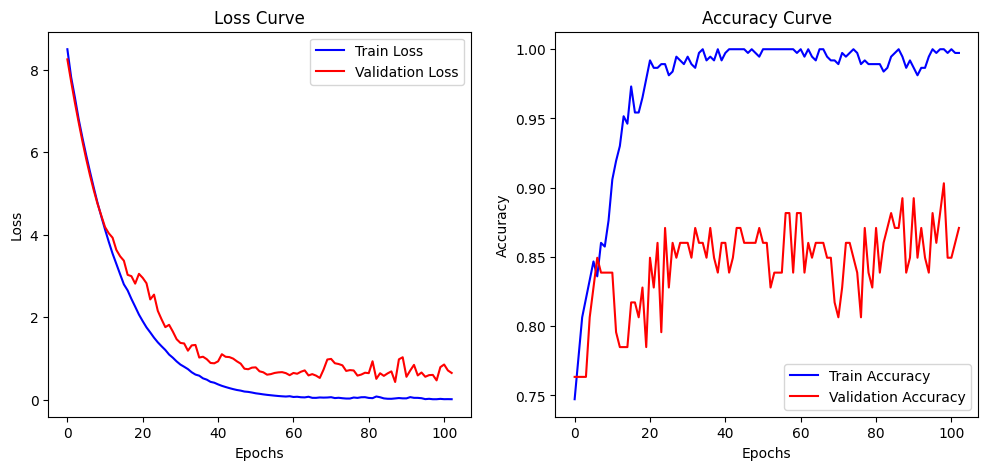

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms

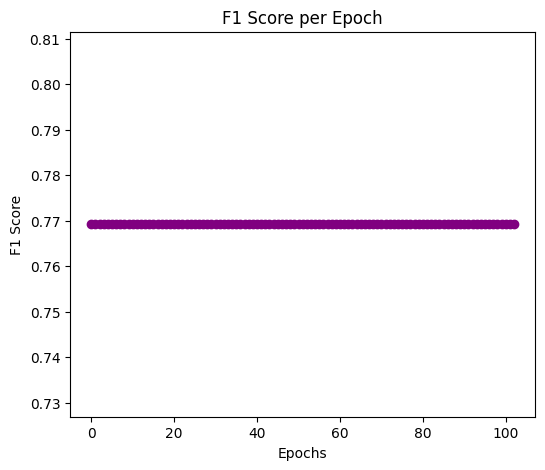

Cohen’s Kappa Score: 0.71
Matthews Correlation Coefficient (MCC): 0.72


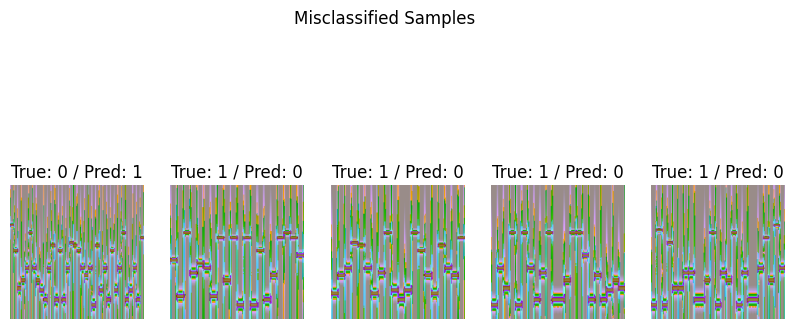


🔟 Performance Metrics Summary Table (For Research Paper)

   Metric  Score
 Accuracy 0.9032
Precision 0.8824
   Recall 0.6818
 F1-score 0.7692
      AUC 0.9046
      MCC 0.7187
   G-mean 0.8140


In [12]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_curve, auc, 
    precision_recall_curve, f1_score, cohen_kappa_score, matthews_corrcoef,
    accuracy_score, precision_score, recall_score
)
import pandas as pd
import random

# 🔹 Get model predictions
y_pred_probs = model.predict(X_test)  # Probabilities
y_pred = (y_pred_probs > 0.5).astype(int)  # Binary labels

# 🔹 1️⃣ Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=["Exp-non-antiviral", "Anti-coronavirus"], 
            yticklabels=["Exp-non-antiviral", "Anti-coronavirus"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

# 🔹 2️⃣ Classification Report
print("\n🔹 Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=["Exp-non-antiviral", "Anti-coronavirus"]))

# 🔹 3️⃣ ROC Curve & AUC Score with shaded area
fpr, tpr, _ = roc_curve(y_test, y_pred_probs)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='blue', label=f'AUC = {roc_auc:.2f}')
plt.fill_between(fpr, tpr, alpha=0.3, color='blue')  # shaded area
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (with AUC Shaded)')
plt.legend()
plt.show()

# 🔹 4️⃣ Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_pred_probs)
plt.figure(figsize=(6,5))
plt.plot(recall, precision, color='blue', label='Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

# 🔹 5️⃣ Training Loss & Accuracy Curves
plt.figure(figsize=(12,5))

# Loss Plot
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='red')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.legend()

# Accuracy Plot
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy Curve')
plt.legend()

plt.show()

# 🔹 6️⃣ F1 Score per Epoch (static due to using test set repeatedly)
f1_scores = [f1_score(y_test, (model.predict(X_test) > 0.5).astype(int)) for _ in range(len(history.history['loss']))]
plt.figure(figsize=(6,5))
plt.plot(f1_scores, color='purple', marker='o')
plt.xlabel('Epochs')
plt.ylabel('F1 Score')
plt.title('F1 Score per Epoch')
plt.show()

# 🔹 7️⃣ Cohen’s Kappa Score
kappa_score = cohen_kappa_score(y_test, y_pred)
print(f"Cohen’s Kappa Score: {kappa_score:.2f}")

# 🔹 8️⃣ Matthews Correlation Coefficient (MCC)
mcc = matthews_corrcoef(y_test, y_pred)
print(f"Matthews Correlation Coefficient (MCC): {mcc:.2f}")

# 🔹 9️⃣ Error Analysis (Misclassified Samples)
misclassified_idx = np.where(y_pred.flatten() != y_test.flatten())[0]
if len(misclassified_idx) > 5:  
    misclassified_idx = random.sample(list(misclassified_idx), 5)

plt.figure(figsize=(10,5))
for i, idx in enumerate(misclassified_idx):
    plt.subplot(1, 5, i + 1)
    plt.imshow(X_test[idx].astype("uint8"))
    plt.title(f"True: {y_test[idx]} / Pred: {y_pred[idx][0]}")
    plt.axis("off")
plt.suptitle("Misclassified Samples")
plt.show()

# 🔟 Performance Metrics Summary Table
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

accuracy = accuracy_score(y_test, y_pred)
precision_val = precision_score(y_test, y_pred)
recall_val = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
sensitivity = recall_val
specificity = tn / (tn + fp)
gmean = np.sqrt(sensitivity * specificity)

performance_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "AUC", "MCC", "G-mean"],
    "Score": [accuracy, precision_val, recall_val, f1, roc_auc, mcc, gmean]
})

print("\n🔟 Performance Metrics Summary Table (For Research Paper)\n")
print(performance_df.round(4).to_string(index=False))


**inception v3**

In [13]:
import os
import numpy as np
from glob import glob
import cv2
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, applications, regularizers
from sklearn.model_selection import train_test_split

# Paths to directories (with full class names)
data_dir_anti_coronavirus = "/kaggle/input/spectrogram-imgs-ennavia-c-mol-mass/spectrogram images/anti-coronavirus images"
data_dir_exp_non_antiviral = "/kaggle/input/spectrogram-imgs-ennavia-c-mol-mass/spectrogram images/exp-non-antiviral images"


# Image dimensions for InceptionV3
IMG_HEIGHT, IMG_WIDTH = 299, 299  
TEST_SIZE = 0.2  # 20% for testing
RANDOM_STATE = 42  # For reproducible splits
BATCH_SIZE = 32

# Function to load and preprocess images
def load_images_from_directory(directory, label):
    images, labels = [], []
    files = glob(os.path.join(directory, "*.png"))  
    for file in files:
        img = cv2.imread(file)
        if img is None:
            continue
        img = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT))  
        img = img / 255.0  # Normalize to [0,1]
        images.append(img)
        labels.append(label)  
    return np.array(images), np.array(labels)

# Load datasets for both classes
X_anti_coronavirus, y_anti_coronavirus = load_images_from_directory(data_dir_anti_coronavirus, label=1)
X_exp_non_antiviral, y_exp_non_antiviral = load_images_from_directory(data_dir_exp_non_antiviral, label=0)

# Combine both classes into single dataset
X = np.concatenate((X_anti_coronavirus, X_exp_non_antiviral), axis=0)
y = np.concatenate((y_anti_coronavirus, y_exp_non_antiviral), axis=0)

# Split into training and testing sets with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=TEST_SIZE, 
    random_state=RANDOM_STATE,
    stratify=y
)

# Shuffle training dataset
indices = np.arange(X_train.shape[0])
np.random.shuffle(indices)
X_train, y_train = X_train[indices], y_train[indices]

# Build InceptionV3 Model
def build_inception_model(input_shape):
    base_model = applications.InceptionV3(
        weights='imagenet', 
        include_top=False, 
        input_shape=input_shape
    )

    # Freeze initial layers, fine-tune last layers
    for layer in base_model.layers[:280]:  
        layer.trainable = False
    for layer in base_model.layers[280:]:
        layer.trainable = True

    inputs = layers.Input(shape=input_shape)
    x = base_model(inputs, training=False)

    # Global Pooling & Dense Layers
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.01))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)  

    model = models.Model(inputs, outputs)

    # Learning rate schedule
    lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
        initial_learning_rate=0.0001, 
        decay_steps=5000, 
        decay_rate=0.9, 
        staircase=True
    )
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)
    
    model.compile(
        optimizer=optimizer, 
        loss='binary_crossentropy', 
        metrics=['accuracy']
    )
    return model

# Instantiate InceptionV3 Model
model = build_inception_model((IMG_HEIGHT, IMG_WIDTH, 3))

# Callbacks
early_stopping = callbacks.EarlyStopping(
    monitor='val_loss', 
    patience=25, 
    restore_best_weights=True
)
model_checkpoint = callbacks.ModelCheckpoint(
    "best_inception_model.keras", 
    monitor='val_accuracy', 
    save_best_only=True
)

# Train Model (without data augmentation)
history = model.fit(
    X_train, y_train, 
    batch_size=BATCH_SIZE, 
    epochs=200,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping, model_checkpoint],
    verbose=1
)

# Load best model and evaluate
model.load_weights("best_inception_model.keras")
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy: {test_accuracy * 100:.2f}%")

# Save model
tf.keras.models.save_model(model, "/kaggle/working/final_InceptionV3_model.keras")
print("Model saved successfully in /kaggle/working/")

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Epoch 1/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 68s 3s/step - accuracy: 0.6249 - loss: 5.4555 - val_accuracy: 0.7957 - val_loss: 5.1128
Epoch 2/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 204ms/step - accuracy: 0.7053 - loss: 5.1136 - val_accuracy: 0.7634 - val_loss: 5.0854
Epoch 3/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 207ms/step - accuracy: 0.7820 - loss: 4.8680 - val_accuracy: 0.7957 - val_loss: 4.9117
Epoch 4/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 323ms/step - accuracy: 0.9015 - loss: 4.6736 - val_accuracy: 0.8387 - val_loss: 4.8428
Epoch 5/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 311ms/step - accuracy: 0.8754 - loss: 4.5810 - val_accuracy: 0.8495 - val_loss: 4.7706
Epoch 6/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 196ms/step - accuracy: 0.9251 - loss: 4.4828 - val_accuracy: 0.8280 - val_loss: 4.6716
Epoch 7/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 196ms/step - accuracy: 0.9483 - loss: 4.3416 - val_accuracy: 0.8172 - val_loss: 4.5863
Epoch 8/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 194ms/

3/3 ━━━━━━━━━━━━━━━━━━━━ 13s 3s/step 


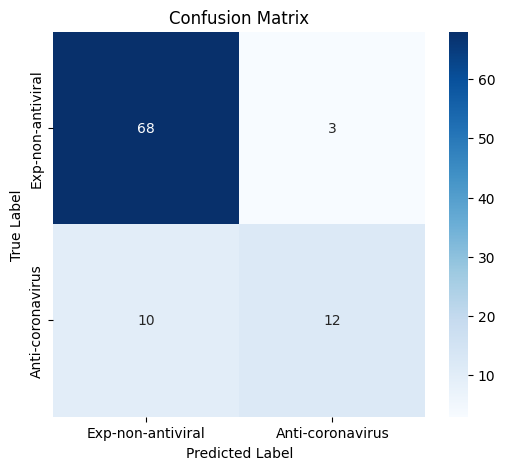


🔹 Classification Report:

                   precision    recall  f1-score   support

Exp-non-antiviral       0.87      0.96      0.91        71
 Anti-coronavirus       0.80      0.55      0.65        22

         accuracy                           0.86        93
        macro avg       0.84      0.75      0.78        93
     weighted avg       0.85      0.86      0.85        93



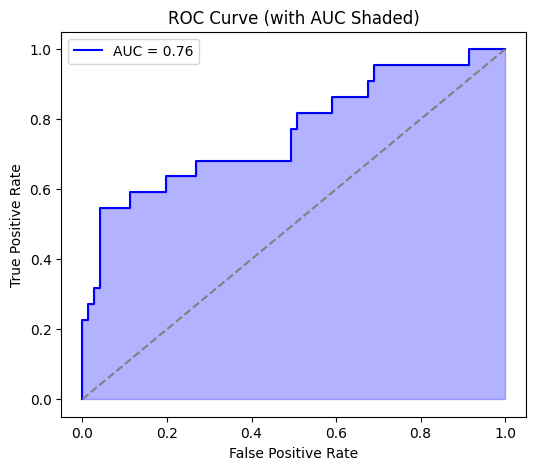

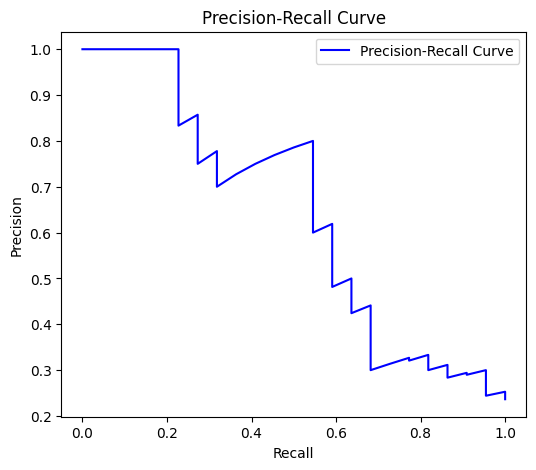

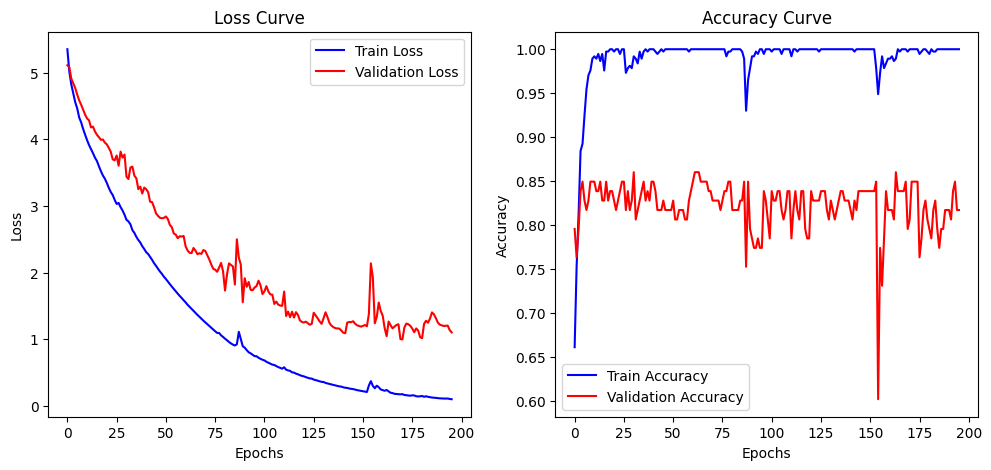

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 

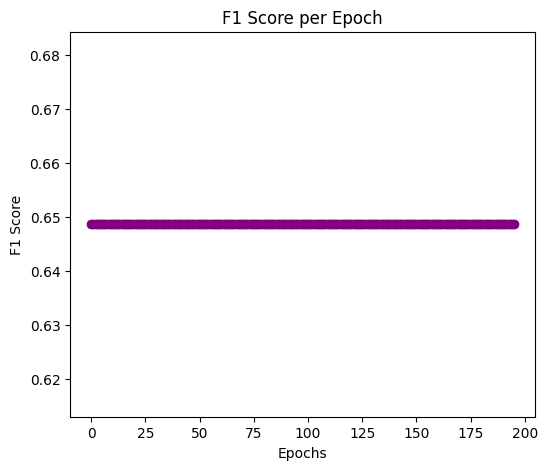

Cohen’s Kappa Score: 0.57
Matthews Correlation Coefficient (MCC): 0.58


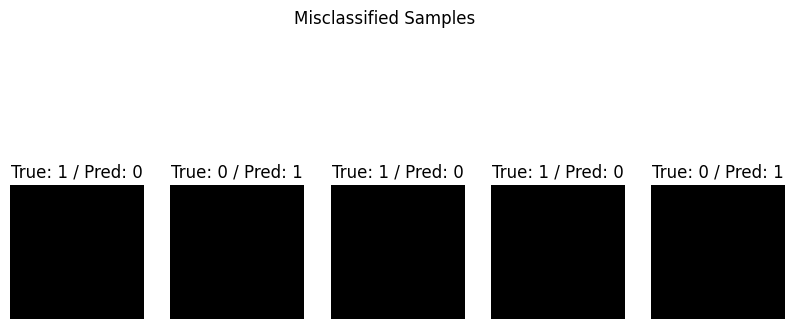


🔟 Performance Metrics Summary Table (For Research Paper)

   Metric  Score
 Accuracy 0.8602
Precision 0.8000
   Recall 0.5455
 F1-score 0.6486
      AUC 0.7638
      MCC 0.5814
   G-mean 0.7228


In [14]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_curve, auc, 
    precision_recall_curve, f1_score, cohen_kappa_score, matthews_corrcoef,
    accuracy_score, precision_score, recall_score
)
import pandas as pd
import random

# 🔹 Get model predictions
y_pred_probs = model.predict(X_test)  # Probabilities
y_pred = (y_pred_probs > 0.5).astype(int)  # Binary labels

# 🔹 1️⃣ Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=["Exp-non-antiviral", "Anti-coronavirus"], 
            yticklabels=["Exp-non-antiviral", "Anti-coronavirus"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

# 🔹 2️⃣ Classification Report
print("\n🔹 Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=["Exp-non-antiviral", "Anti-coronavirus"]))

# 🔹 3️⃣ ROC Curve & AUC Score with shaded area
fpr, tpr, _ = roc_curve(y_test, y_pred_probs)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='blue', label=f'AUC = {roc_auc:.2f}')
plt.fill_between(fpr, tpr, alpha=0.3, color='blue')  # shaded area
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (with AUC Shaded)')
plt.legend()
plt.show()

# 🔹 4️⃣ Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_pred_probs)
plt.figure(figsize=(6,5))
plt.plot(recall, precision, color='blue', label='Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

# 🔹 5️⃣ Training Loss & Accuracy Curves
plt.figure(figsize=(12,5))

# Loss Plot
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='red')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.legend()

# Accuracy Plot
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy Curve')
plt.legend()

plt.show()

# 🔹 6️⃣ F1 Score per Epoch (static due to using test set repeatedly)
f1_scores = [f1_score(y_test, (model.predict(X_test) > 0.5).astype(int)) for _ in range(len(history.history['loss']))]
plt.figure(figsize=(6,5))
plt.plot(f1_scores, color='purple', marker='o')
plt.xlabel('Epochs')
plt.ylabel('F1 Score')
plt.title('F1 Score per Epoch')
plt.show()

# 🔹 7️⃣ Cohen’s Kappa Score
kappa_score = cohen_kappa_score(y_test, y_pred)
print(f"Cohen’s Kappa Score: {kappa_score:.2f}")

# 🔹 8️⃣ Matthews Correlation Coefficient (MCC)
mcc = matthews_corrcoef(y_test, y_pred)
print(f"Matthews Correlation Coefficient (MCC): {mcc:.2f}")

# 🔹 9️⃣ Error Analysis (Misclassified Samples)
misclassified_idx = np.where(y_pred.flatten() != y_test.flatten())[0]
if len(misclassified_idx) > 5:  
    misclassified_idx = random.sample(list(misclassified_idx), 5)

plt.figure(figsize=(10,5))
for i, idx in enumerate(misclassified_idx):
    plt.subplot(1, 5, i + 1)
    plt.imshow(X_test[idx].astype("uint8"))
    plt.title(f"True: {y_test[idx]} / Pred: {y_pred[idx][0]}")
    plt.axis("off")
plt.suptitle("Misclassified Samples")
plt.show()

# 🔟 Performance Metrics Summary Table
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

accuracy = accuracy_score(y_test, y_pred)
precision_val = precision_score(y_test, y_pred)
recall_val = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
sensitivity = recall_val
specificity = tn / (tn + fp)
gmean = np.sqrt(sensitivity * specificity)

performance_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "AUC", "MCC", "G-mean"],
    "Score": [accuracy, precision_val, recall_val, f1, roc_auc, mcc, gmean]
})

print("\n🔟 Performance Metrics Summary Table (For Research Paper)\n")
print(performance_df.round(4).to_string(index=False))


**inception v3+SE**

In [15]:
import os
import numpy as np
from glob import glob
import cv2
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.applications.inception_v3 import preprocess_input
from sklearn.model_selection import train_test_split

# Paths to directories (Update with your Ennavia C dataset paths)
data_dir_anti_coronavirus = "/kaggle/input/spectrogram-imgs-ennavia-c-mol-mass/spectrogram images/anti-coronavirus images"
data_dir_exp_non_antiviral = "/kaggle/input/spectrogram-imgs-ennavia-c-mol-mass/spectrogram images/exp-non-antiviral images"


# Image dimensions
IMG_HEIGHT, IMG_WIDTH = 299, 299  # InceptionV3 input size
TEST_SIZE = 0.2  # 20% for testing
RANDOM_STATE = 42  # For reproducible splits

# Function to load and preprocess images
def load_images_from_directory(directory, label):
    images, labels = [], []
    files = glob(os.path.join(directory, "*.png"))
    for file in files:
        img = cv2.imread(file)
        if img is None:
            continue
        img = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT))  
        img = preprocess_input(img)  
        images.append(img)
        labels.append(label)
    return np.array(images), np.array(labels)

# Load datasets for both classes
X_anti_corona, y_anti_corona = load_images_from_directory(data_dir_anti_coronavirus, label=1)
X_exp_non_antiviral, y_exp_non_antiviral = load_images_from_directory(data_dir_exp_non_antiviral, label=0)

# Combine datasets
X = np.concatenate((X_anti_corona, X_exp_non_antiviral), axis=0)
y = np.concatenate((y_anti_corona, y_exp_non_antiviral), axis=0)

# Split into training and testing sets with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=TEST_SIZE, 
    random_state=RANDOM_STATE,
    stratify=y
)

# Shuffle training dataset
indices = np.arange(X_train.shape[0])
np.random.shuffle(indices)
X_train, y_train = X_train[indices], y_train[indices]

# Data Augmentation (same as original code)
datagen = ImageDataGenerator(
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.8, 1.2]
)

# Squeeze-and-Excitation (SE) Attention Block (same as original)
def se_block(input_tensor, ratio=16):
    """Squeeze-and-Excitation Block"""
    channel = input_tensor.shape[-1]

    # Squeeze: Global Average Pooling
    se = layers.GlobalAveragePooling2D()(input_tensor)
    se = layers.Dense(channel // ratio, activation='relu')(se)  # Bottleneck
    se = layers.Dense(channel, activation='sigmoid')(se)  # Excitation

    se = layers.Reshape((1, 1, channel))(se)  # Reshape for broadcasting
    x = layers.Multiply()([input_tensor, se])  # Apply channel attention
    return x

# Define InceptionV3 Model with SE Attention (same as original)
def build_inception_se_model(input_shape):
    base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=input_shape)

    # Freeze first layers
    for layer in base_model.layers[:249]:  
        layer.trainable = False
    for layer in base_model.layers[249:]:  
        layer.trainable = True

    # Apply SE Attention to last convolutional block
    x = se_block(base_model.output)

    # Classification Head
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.01))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = models.Model(inputs=base_model.input, outputs=outputs)

    # Compile Model with Exponential Decay Learning Rate
    initial_learning_rate = 0.0001
    lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
        initial_learning_rate, decay_steps=10000, decay_rate=0.9, staircase=True)
    
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

    return model

# Instantiate model with SE Attention
model = build_inception_se_model((IMG_HEIGHT, IMG_WIDTH, 3))

# Callbacks (same as original)
early_stopping = callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
model_checkpoint = callbacks.ModelCheckpoint("best_se_inception_model.keras", monitor='val_accuracy', save_best_only=True)

# Train model with data augmentation (same as original)
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    epochs=200,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping, model_checkpoint],
    verbose=1
)

# Evaluate Model
model.load_weights("best_se_inception_model.keras")
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy with SE Attention: {test_accuracy * 100:.2f}%")

# Save model
tf.keras.models.save_model(model, "/kaggle/working/final_InceptionV3+SE_model.keras")
print("Model saved successfully in /kaggle/working/")

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 56s 2s/step - accuracy: 0.6354 - loss: 8.9603 - val_accuracy: 0.3656 - val_loss: 8.7432
Epoch 2/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 270ms/step - accuracy: 0.7214 - loss: 8.6337 - val_accuracy: 0.2473 - val_loss: 8.6109
Epoch 3/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 390ms/step - accuracy: 0.7733 - loss: 8.3159 - val_accuracy: 0.5591 - val_loss: 8.3911
Epoch 4/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 388ms/step - accuracy: 0.8124 - loss: 8.0625 - val_accuracy: 0.7419 - val_loss: 8.2214
Epoch 5/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 379ms/step - accuracy: 0.8477 - loss: 7.9392 - val_accuracy: 0.8387 - val_loss: 8.0451
Epoch 6/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 395ms/step - accuracy: 0.8891 - loss: 7.6828 - val_accuracy: 0.8495 - val_loss: 7.8766
Epoch 7/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 261ms/step - accuracy: 0.9264 - loss: 7.4779 - val_accuracy: 0.8387 - val_loss: 7.6703
Epoch 8/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 276ms/step - accuracy: 0.8967 - loss: 7.3564 - val_accura

3/3 ━━━━━━━━━━━━━━━━━━━━ 13s 3s/step 


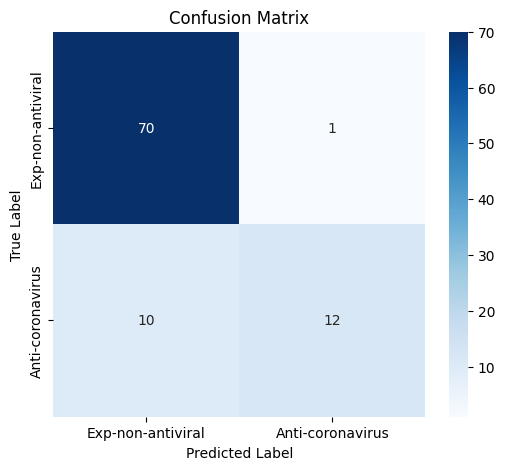


🔹 Classification Report:

                   precision    recall  f1-score   support

Exp-non-antiviral       0.88      0.99      0.93        71
 Anti-coronavirus       0.92      0.55      0.69        22

         accuracy                           0.88        93
        macro avg       0.90      0.77      0.81        93
     weighted avg       0.89      0.88      0.87        93



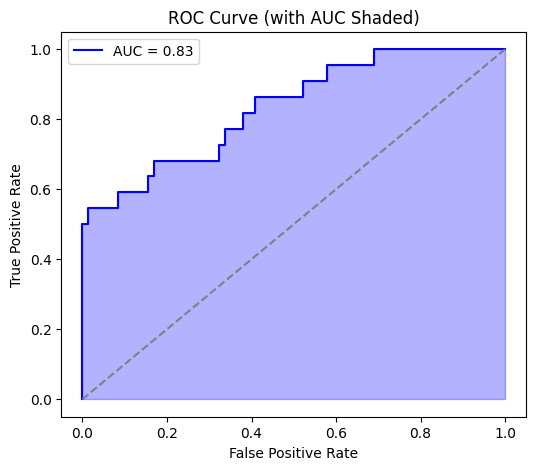

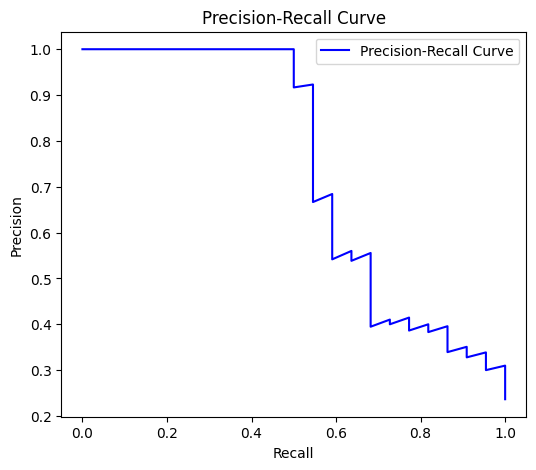

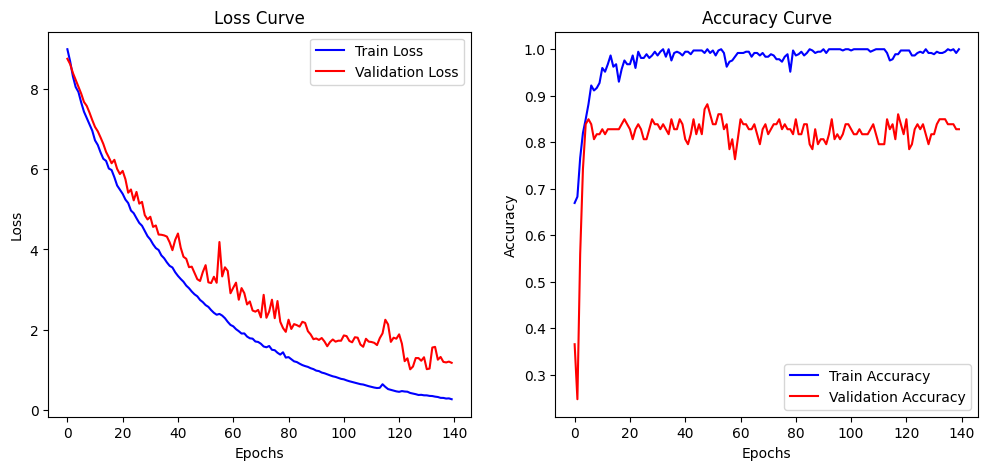

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 

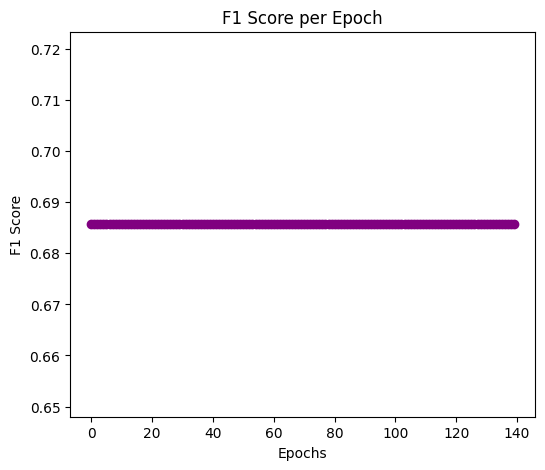

Cohen’s Kappa Score: 0.62
Matthews Correlation Coefficient (MCC): 0.65


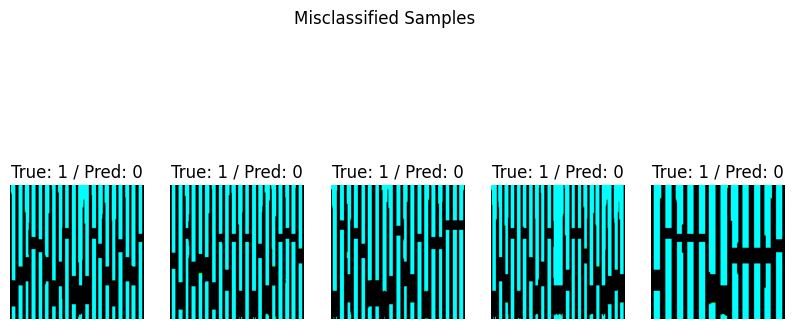


🔟 Performance Metrics Summary Table (For Research Paper)

   Metric  Score
 Accuracy 0.8817
Precision 0.9231
   Recall 0.5455
 F1-score 0.6857
      AUC 0.8335
      MCC 0.6512
   G-mean 0.7333


In [16]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_curve, auc, 
    precision_recall_curve, f1_score, cohen_kappa_score, matthews_corrcoef,
    accuracy_score, precision_score, recall_score
)
import pandas as pd
import random

# 🔹 Get model predictions
y_pred_probs = model.predict(X_test)  # Probabilities
y_pred = (y_pred_probs > 0.5).astype(int)  # Binary labels

# 🔹 1️⃣ Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=["Exp-non-antiviral", "Anti-coronavirus"], 
            yticklabels=["Exp-non-antiviral", "Anti-coronavirus"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

# 🔹 2️⃣ Classification Report
print("\n🔹 Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=["Exp-non-antiviral", "Anti-coronavirus"]))

# 🔹 3️⃣ ROC Curve & AUC Score with shaded area
fpr, tpr, _ = roc_curve(y_test, y_pred_probs)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='blue', label=f'AUC = {roc_auc:.2f}')
plt.fill_between(fpr, tpr, alpha=0.3, color='blue')  # shaded area
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (with AUC Shaded)')
plt.legend()
plt.show()

# 🔹 4️⃣ Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_pred_probs)
plt.figure(figsize=(6,5))
plt.plot(recall, precision, color='blue', label='Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

# 🔹 5️⃣ Training Loss & Accuracy Curves
plt.figure(figsize=(12,5))

# Loss Plot
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='red')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.legend()

# Accuracy Plot
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy Curve')
plt.legend()

plt.show()

# 🔹 6️⃣ F1 Score per Epoch (static due to using test set repeatedly)
f1_scores = [f1_score(y_test, (model.predict(X_test) > 0.5).astype(int)) for _ in range(len(history.history['loss']))]
plt.figure(figsize=(6,5))
plt.plot(f1_scores, color='purple', marker='o')
plt.xlabel('Epochs')
plt.ylabel('F1 Score')
plt.title('F1 Score per Epoch')
plt.show()

# 🔹 7️⃣ Cohen’s Kappa Score
kappa_score = cohen_kappa_score(y_test, y_pred)
print(f"Cohen’s Kappa Score: {kappa_score:.2f}")

# 🔹 8️⃣ Matthews Correlation Coefficient (MCC)
mcc = matthews_corrcoef(y_test, y_pred)
print(f"Matthews Correlation Coefficient (MCC): {mcc:.2f}")

# 🔹 9️⃣ Error Analysis (Misclassified Samples)
misclassified_idx = np.where(y_pred.flatten() != y_test.flatten())[0]
if len(misclassified_idx) > 5:  
    misclassified_idx = random.sample(list(misclassified_idx), 5)

plt.figure(figsize=(10,5))
for i, idx in enumerate(misclassified_idx):
    plt.subplot(1, 5, i + 1)
    plt.imshow(X_test[idx].astype("uint8"))
    plt.title(f"True: {y_test[idx]} / Pred: {y_pred[idx][0]}")
    plt.axis("off")
plt.suptitle("Misclassified Samples")
plt.show()

# 🔟 Performance Metrics Summary Table
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

accuracy = accuracy_score(y_test, y_pred)
precision_val = precision_score(y_test, y_pred)
recall_val = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
sensitivity = recall_val
specificity = tn / (tn + fp)
gmean = np.sqrt(sensitivity * specificity)

performance_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "AUC", "MCC", "G-mean"],
    "Score": [accuracy, precision_val, recall_val, f1, roc_auc, mcc, gmean]
})

print("\n🔟 Performance Metrics Summary Table (For Research Paper)\n")
print(performance_df.round(4).to_string(index=False))


**inception v3 +CBAM**

In [17]:
import os
import numpy as np
from glob import glob
import cv2
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.applications.inception_v3 import preprocess_input
from sklearn.model_selection import train_test_split

# Paths to directories (Update with your Ennavia C dataset paths)
data_dir_anti_coronavirus = "/kaggle/input/spectrogram-imgs-ennavia-c-mol-mass/spectrogram images/anti-coronavirus images"
data_dir_exp_non_antiviral = "/kaggle/input/spectrogram-imgs-ennavia-c-mol-mass/spectrogram images/exp-non-antiviral images"

# Image dimensions
IMG_HEIGHT, IMG_WIDTH = 299, 299  # InceptionV3 expects 299x299 images
TEST_SIZE = 0.2  # 20% for testing
RANDOM_STATE = 42  # For reproducible splits

# Function to load and preprocess images
def load_images_from_directory(directory, label):
    images, labels = [], []
    files = glob(os.path.join(directory, "*.png"))  
    for file in files:
        img = cv2.imread(file)
        if img is None:
            continue
        img = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT))  
        img = preprocess_input(img)  
        images.append(img)
        labels.append(label)  
    return np.array(images), np.array(labels)

# Load datasets for both classes
X_anti_corona, y_anti_corona = load_images_from_directory(data_dir_anti_coronavirus, label=1)
X_exp_non_antiviral, y_exp_non_antiviral = load_images_from_directory(data_dir_exp_non_antiviral, label=0)

# Combine datasets
X = np.concatenate((X_anti_corona, X_exp_non_antiviral), axis=0)
y = np.concatenate((y_anti_corona, y_exp_non_antiviral), axis=0)

# Split into training and testing sets with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=TEST_SIZE, 
    random_state=RANDOM_STATE,
    stratify=y
)

# Shuffle training dataset
indices = np.arange(X_train.shape[0])
np.random.shuffle(indices)
X_train, y_train = X_train[indices], y_train[indices]

# Data Augmentation (same as original)
datagen = ImageDataGenerator(
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.8, 1.2]
)

# CBAM Attention Block (same as original)
def cbam_block(feature_map, ratio=8):
    """CBAM Attention Mechanism"""
    
    # Channel Attention
    channel_avg = layers.GlobalAveragePooling2D()(feature_map)
    channel_max = layers.GlobalMaxPooling2D()(feature_map)
    channel_concat = layers.Concatenate()([channel_avg, channel_max])
    
    channel_dense = layers.Dense(feature_map.shape[-1] // ratio, activation='relu')(channel_concat)
    channel_dense = layers.Dense(feature_map.shape[-1], activation='sigmoid')(channel_dense)
    
    channel_dense = layers.Reshape((1, 1, feature_map.shape[-1]))(channel_dense)
    channel_attention = layers.Multiply()([feature_map, channel_dense])
    
    # Spatial Attention
    spatial_avg = layers.Lambda(lambda x: tf.reduce_mean(x, axis=-1, keepdims=True))(channel_attention)
    spatial_max = layers.Lambda(lambda x: tf.reduce_max(x, axis=-1, keepdims=True))(channel_attention)
    spatial_concat = layers.Concatenate(axis=-1)([spatial_avg, spatial_max])
    
    spatial_attention = layers.Conv2D(1, kernel_size=7, activation='sigmoid', padding='same')(spatial_concat)
    spatial_attention = layers.Multiply()([channel_attention, spatial_attention])
    
    return spatial_attention

# Define InceptionV3 Model with CBAM (same as original)
def build_inception_cbam_model(input_shape):
    base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=input_shape)

    # Freeze initial layers
    for layer in base_model.layers[:249]:  
        layer.trainable = False
    for layer in base_model.layers[249:]:  
        layer.trainable = True

    # Apply CBAM Attention
    x = cbam_block(base_model.output)

    # Custom classification head
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.01))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = models.Model(inputs=base_model.input, outputs=outputs)
    
    # Compile model
    initial_learning_rate = 0.0001
    lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
        initial_learning_rate, decay_steps=10000, decay_rate=0.9, staircase=True)
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)

    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
    
    return model

# Instantiate model with CBAM
model = build_inception_cbam_model((IMG_HEIGHT, IMG_WIDTH, 3))

# Callbacks (same as original)
early_stopping = callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
model_checkpoint = callbacks.ModelCheckpoint("best_cbam_inception_model.keras", monitor='val_accuracy', save_best_only=True)

# Train model with data augmentation (same as original)
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    epochs=200,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping, model_checkpoint],
    verbose=1
)

# Load best model and evaluate
model.load_weights("best_cbam_inception_model.keras")
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy with CBAM: {test_accuracy * 100:.2f}%")

# Save model
tf.keras.models.save_model(model, "/kaggle/working/final_InceptionV3+CBAM_model.keras")
print("Model saved successfully in /kaggle/working/")

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 57s 2s/step - accuracy: 0.5832 - loss: 8.9741 - val_accuracy: 0.8387 - val_loss: 8.6681
Epoch 2/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 255ms/step - accuracy: 0.7140 - loss: 8.5408 - val_accuracy: 0.7957 - val_loss: 8.4607
Epoch 3/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 260ms/step - accuracy: 0.7850 - loss: 8.2315 - val_accuracy: 0.8172 - val_loss: 8.2496
Epoch 4/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 261ms/step - accuracy: 0.8723 - loss: 7.8783 - val_accuracy: 0.8280 - val_loss: 8.0431
Epoch 5/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 265ms/step - accuracy: 0.8731 - loss: 7.6840 - val_accuracy: 0.8387 - val_loss: 7.8166
Epoch 6/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 269ms/step - accuracy: 0.9428 - loss: 7.3664 - val_accuracy: 0.8172 - val_loss: 7.5780
Epoch 7/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 284ms/step - accuracy: 0.9019 - loss: 7.1414 - val_accuracy: 0.8280 - val_loss: 7.3731
Epoch 8/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 238ms/step - accuracy: 0.9439 - loss: 6.9096 - val_accura

3/3 ━━━━━━━━━━━━━━━━━━━━ 15s 4s/step 


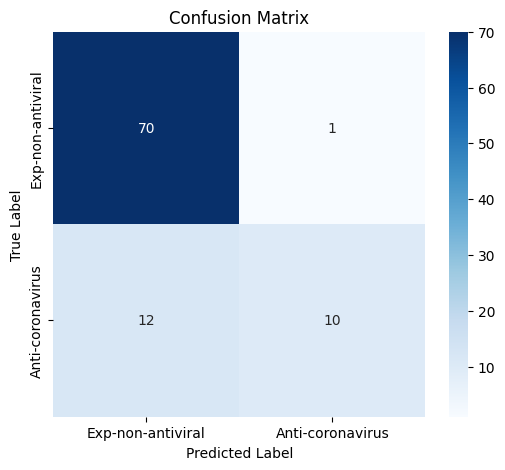


🔹 Classification Report:

                   precision    recall  f1-score   support

Exp-non-antiviral       0.85      0.99      0.92        71
 Anti-coronavirus       0.91      0.45      0.61        22

         accuracy                           0.86        93
        macro avg       0.88      0.72      0.76        93
     weighted avg       0.87      0.86      0.84        93



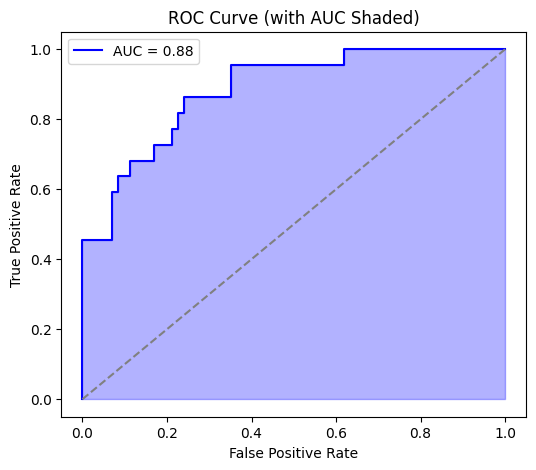

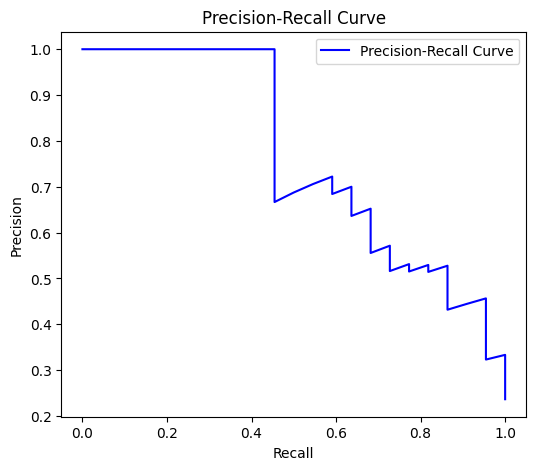

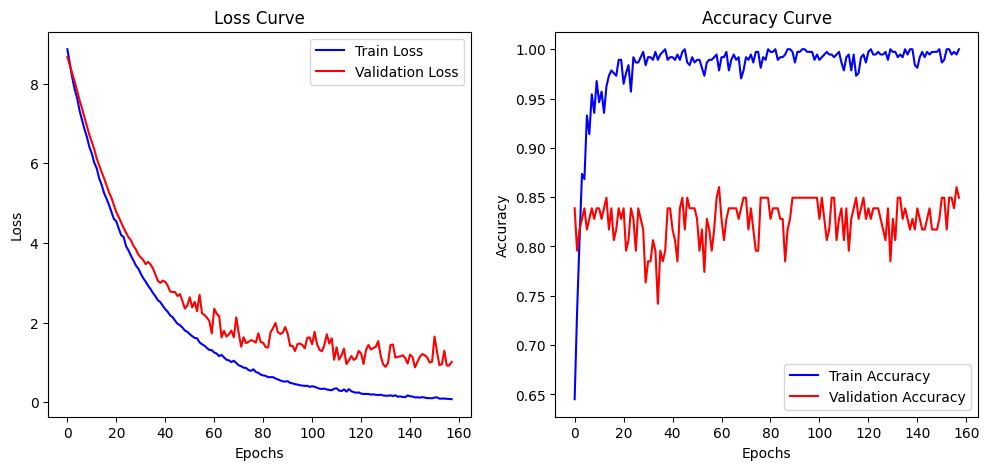

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 

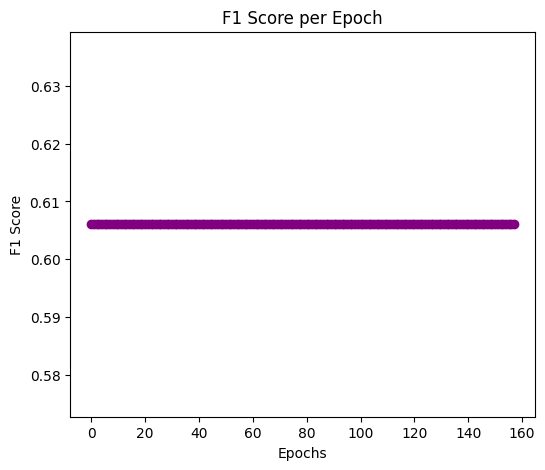

Cohen’s Kappa Score: 0.53
Matthews Correlation Coefficient (MCC): 0.58


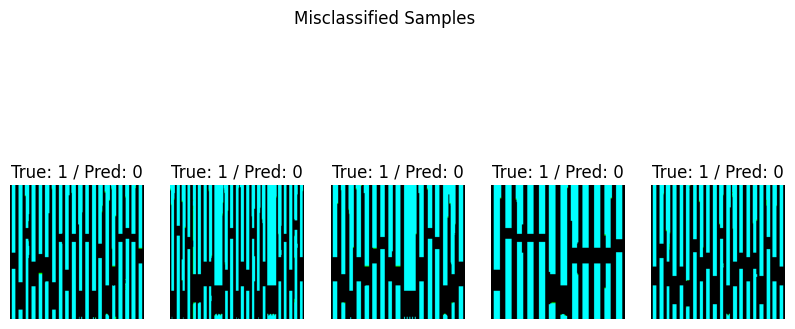


🔟 Performance Metrics Summary Table (For Research Paper)

   Metric  Score
 Accuracy 0.8602
Precision 0.9091
   Recall 0.4545
 F1-score 0.6061
      AUC 0.8828
      MCC 0.5796
   G-mean 0.6694


In [18]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_curve, auc, 
    precision_recall_curve, f1_score, cohen_kappa_score, matthews_corrcoef,
    accuracy_score, precision_score, recall_score
)
import pandas as pd
import random

# 🔹 Get model predictions
y_pred_probs = model.predict(X_test)  # Probabilities
y_pred = (y_pred_probs > 0.5).astype(int)  # Binary labels

# 🔹 1️⃣ Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=["Exp-non-antiviral", "Anti-coronavirus"], 
            yticklabels=["Exp-non-antiviral", "Anti-coronavirus"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

# 🔹 2️⃣ Classification Report
print("\n🔹 Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=["Exp-non-antiviral", "Anti-coronavirus"]))

# 🔹 3️⃣ ROC Curve & AUC Score with shaded area
fpr, tpr, _ = roc_curve(y_test, y_pred_probs)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='blue', label=f'AUC = {roc_auc:.2f}')
plt.fill_between(fpr, tpr, alpha=0.3, color='blue')  # shaded area
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (with AUC Shaded)')
plt.legend()
plt.show()

# 🔹 4️⃣ Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_pred_probs)
plt.figure(figsize=(6,5))
plt.plot(recall, precision, color='blue', label='Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

# 🔹 5️⃣ Training Loss & Accuracy Curves
plt.figure(figsize=(12,5))

# Loss Plot
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='red')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.legend()

# Accuracy Plot
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy Curve')
plt.legend()

plt.show()

# 🔹 6️⃣ F1 Score per Epoch (static due to using test set repeatedly)
f1_scores = [f1_score(y_test, (model.predict(X_test) > 0.5).astype(int)) for _ in range(len(history.history['loss']))]
plt.figure(figsize=(6,5))
plt.plot(f1_scores, color='purple', marker='o')
plt.xlabel('Epochs')
plt.ylabel('F1 Score')
plt.title('F1 Score per Epoch')
plt.show()

# 🔹 7️⃣ Cohen’s Kappa Score
kappa_score = cohen_kappa_score(y_test, y_pred)
print(f"Cohen’s Kappa Score: {kappa_score:.2f}")

# 🔹 8️⃣ Matthews Correlation Coefficient (MCC)
mcc = matthews_corrcoef(y_test, y_pred)
print(f"Matthews Correlation Coefficient (MCC): {mcc:.2f}")

# 🔹 9️⃣ Error Analysis (Misclassified Samples)
misclassified_idx = np.where(y_pred.flatten() != y_test.flatten())[0]
if len(misclassified_idx) > 5:  
    misclassified_idx = random.sample(list(misclassified_idx), 5)

plt.figure(figsize=(10,5))
for i, idx in enumerate(misclassified_idx):
    plt.subplot(1, 5, i + 1)
    plt.imshow(X_test[idx].astype("uint8"))
    plt.title(f"True: {y_test[idx]} / Pred: {y_pred[idx][0]}")
    plt.axis("off")
plt.suptitle("Misclassified Samples")
plt.show()

# 🔟 Performance Metrics Summary Table
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

accuracy = accuracy_score(y_test, y_pred)
precision_val = precision_score(y_test, y_pred)
recall_val = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
sensitivity = recall_val
specificity = tn / (tn + fp)
gmean = np.sqrt(sensitivity * specificity)

performance_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "AUC", "MCC", "G-mean"],
    "Score": [accuracy, precision_val, recall_val, f1, roc_auc, mcc, gmean]
})

print("\n🔟 Performance Metrics Summary Table (For Research Paper)\n")
print(performance_df.round(4).to_string(index=False))
